# MP-EVData: Electric Vehicle Charging Load Analysis

## Reproducible Analysis Notebook

This notebook performs data preprocessing, exploratory analysis, charging pattern characterization, machine learning classification, SHAP interpretation, and charging simultaneity analysis using the MP-EVData dataset.

### Analysis Workflow

1. Dataset loading and validation
2. Data cleaning and preprocessing
3. Station-level load pattern analysis
4. Daily charging profile analysis
5. K-means clustering
6. Random Forest classification
7. SHAP model interpretation
8. Charging simultaneity calculation
9. Time-of-use price response analysis

Dataset:
MP-EVData (Scientific Data, 2026)

Resolution:
15-minute charging load data

## Reproducibility Instructions

This notebook provides a complete workflow for reproducing the MP-EVData charging load analysis.

### Required steps

1. Download the MP-EVData dataset.
2. Upload the dataset ZIP file when prompted by the notebook.
3. Run all cells sequentially from beginning to end.

The notebook automatically performs:

- Dataset extraction
- Data quality assessment
- Data preprocessing
- Station-level load analysis
- Daily charging profile analysis
- Peak–valley difference calculation
- Load factor analysis
- K-means clustering
- Random Forest classification
- SHAP interpretation
- Charging simultaneity analysis
- TOU price response analysis

All figures and result files are automatically generated in the project folders.

## 1. Environment Setup and Dataset Loading

This section imports the required Python libraries, uploads the MP-EVData dataset archive, extracts the raw data, and prepares the working environment for analysis.

In [12]:
# ============================================================
# 1. Environment setup and dataset loading
# ============================================================

from pathlib import Path
import zipfile
import shutil
import re
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib

from google.colab import files

uploaded = files.upload()

uploaded_zips = [
    Path("/content") / filename
    for filename in uploaded
    if filename.lower().endswith(".zip")
]

if len(uploaded_zips) != 1:
    raise ValueError(
        "Upload exactly one ZIP file: the original MP-EVData dataset."
    )

zip_path = uploaded_zips[0]
extract_folder = Path("/content/MP_EVData")
extract_folder.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as archive:
    archive.extractall(extract_folder)

load_files = list(
    extract_folder.rglob("station-level load Profile 15min.xlsx")
)
price_files = list(
    extract_folder.rglob("price.xlsx")
)

if len(load_files) != 1:
    raise FileNotFoundError(
        f"Expected one station-load workbook; found {len(load_files)}."
    )

if len(price_files) != 1:
    raise FileNotFoundError(
        f"Expected one price workbook; found {len(price_files)}."
    )

load_path = load_files[0]
price_path = price_files[0]

workbook_path = load_path
file_path = str(load_path)
workbook = pd.ExcelFile(load_path)

print("Dataset ZIP:", zip_path.name)
print("Load workbook:", load_path)
print("Price workbook:", price_path)
print("Station sheets:", workbook.sheet_names)

Saving 29882366.zip to 29882366 (2).zip
Dataset ZIP: 29882366 (2).zip
Load workbook: /content/MP_EVData/dataset/station-level load Profile 15min.xlsx
Price workbook: /content/MP_EVData/dataset/price.xlsx
Station sheets: ['站点确定', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']


In [13]:
# Read taxi station A1 into a Python table
df_a1 = pd.read_excel(workbook, sheet_name="A1")

# Display the first five rows
display(df_a1.head())

# Print the number of rows and columns
print("Rows:", df_a1.shape[0])
print("Columns:", df_a1.shape[1])

,datetime,power
0,2024-01-01 00:00:00,184.4
1,2024-01-01 00:15:00,115.4
2,2024-01-01 00:30:00,275.2
3,2024-01-01 00:45:00,238.7
4,2024-01-01 01:00:00,313.8


Rows: 35232
Columns: 2


## 2. Data Quality Assessment

This section validates the dataset before analysis.

The checks include:

- Data type verification
- Timestamp range validation
- Missing value detection
- Duplicate timestamp detection
- Negative value checks
- 15-minute interval consistency
- Year coverage verification

In [14]:
# Check how Python interprets each column
print("DATA TYPES")
print(df_a1.dtypes)

# Check the date range
print("\nDATE RANGE")
print("Earliest:", df_a1["datetime"].min())
print("Latest:", df_a1["datetime"].max())

# Count missing values
print("\nMISSING VALUES")
print(df_a1.isna().sum())

# Check repeated timestamps and negative power
print("\nOTHER CHECKS")
print("Duplicate timestamps:", df_a1["datetime"].duplicated().sum())
print("Negative power values:", (df_a1["power"] < 0).sum())

DATA TYPES
datetime    datetime64[ns]
power              float64
dtype: object

DATE RANGE
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00

MISSING VALUES
datetime    0
power       0
dtype: int64

OTHER CHECKS
Duplicate timestamps: 0
Negative power values: 0


In [15]:
# Select dates within calendar year 2024
mask_2024 = (
    (df_a1["datetime"] >= "2024-01-01")
    & (df_a1["datetime"] < "2025-01-01")
)

# Copy selected rows and put them in chronological order
df_a1_2024 = (
    df_a1.loc[mask_2024]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Original rows:", len(df_a1))
print("2024 rows:", len(df_a1_2024))
print("Rows outside 2024:", len(df_a1) - len(df_a1_2024))

print("\nFirst timestamp:", df_a1_2024["datetime"].min())
print("Last timestamp:", df_a1_2024["datetime"].max())

Original rows: 35232
2024 rows: 35136
Rows outside 2024: 96

First timestamp: 2024-01-01 00:00:00
Last timestamp: 2024-12-31 23:45:00


In [16]:
# Generate every expected 15-minute timestamp in 2024
expected_times = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

# Get the timestamps actually present in our table
actual_times = pd.DatetimeIndex(df_a1_2024["datetime"])

# Compare expected and actual timestamps
missing_times = expected_times.difference(actual_times)
unexpected_times = actual_times.difference(expected_times)

print("Expected intervals:", len(expected_times))
print("Actual rows:", len(actual_times))
print("Missing timestamps:", len(missing_times))
print("Unexpected timestamps:", len(unexpected_times))

Expected intervals: 35136
Actual rows: 35136
Missing timestamps: 0
Unexpected timestamps: 0


## 3. Station-Level Load Profile Analysis

This section examines the charging load behavior of individual EV charging stations.

The analysis includes:

- Daily charging load curve visualization
- Station-level power variation over time
- Identification of charging demand patterns
- Comparison of station operating characteristics

Intervals in this day: 96


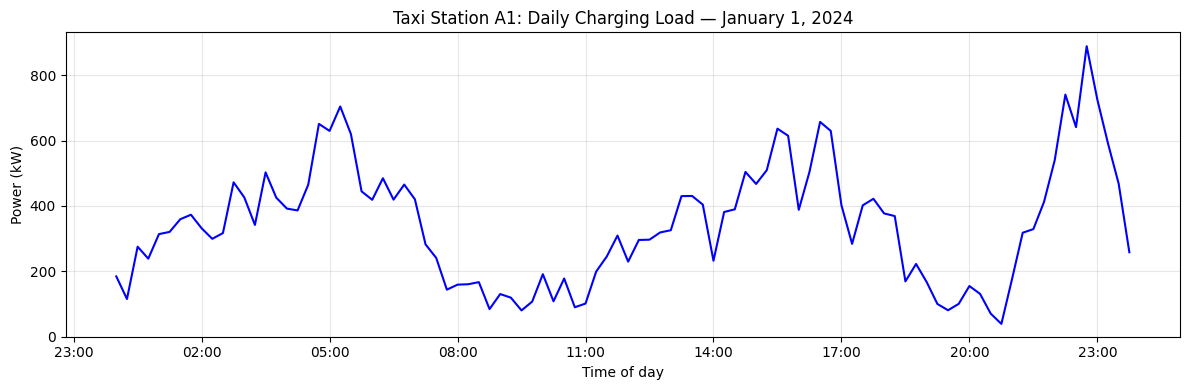

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Select one day
selected_day = pd.Timestamp("2024-01-01")

day_data = df_a1_2024.loc[
    (df_a1_2024["datetime"] >= selected_day)
    & (df_a1_2024["datetime"] < selected_day + pd.Timedelta(days=1))
].copy()

print("Intervals in this day:", len(day_data))

# Draw the load curve
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(day_data["datetime"], day_data["power"], color="blue")

ax.set_title("Taxi Station A1: Daily Charging Load — January 1, 2024")
ax.set_xlabel("Time of day")
ax.set_ylabel("Power (kW)")
ax.set_ylim(bottom=0)

# Display time labels every three hours
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Calculate daily load metrics
peak = day_data["power"].max()
valley = day_data["power"].min()
average = day_data["power"].mean()

peak_valley_difference = peak - valley
load_factor = average / peak if peak > 0 else float("nan")

# Find when the maximum and minimum occurred
peak_time = day_data.loc[
    day_data["power"].idxmax(), "datetime"
]

valley_time = day_data.loc[
    day_data["power"].idxmin(), "datetime"
]

print(f"Peak load: {peak:.2f} kW")
print(f"Peak time: {peak_time:%H:%M}")

print(f"\nValley load: {valley:.2f} kW")
print(f"Valley time: {valley_time:%H:%M}")

print(f"\nAverage load: {average:.2f} kW")
print(f"Peak–valley difference: {peak_valley_difference:.2f} kW")
print(f"Load factor: {load_factor:.3f} ({load_factor:.1%})")

Peak load: 888.40 kW
Peak time: 22:45

Valley load: 39.20 kW
Valley time: 20:45

Average load: 344.99 kW
Peak–valley difference: 849.20 kW
Load factor: 0.388 (38.8%)


In [19]:
# Create a separate working table with a date column
a1_features = df_a1_2024.copy()
a1_features["date"] = a1_features["datetime"].dt.date

# Group intervals by date and summarize each day's power
daily_metrics_a1 = (
    a1_features.groupby("date")
    .agg(
        intervals=("power", "count"),
        average_kW=("power", "mean"),
        peak_kW=("power", "max"),
        valley_kW=("power", "min")
    )
)

# Calculate additional daily features
daily_metrics_a1["peak_valley_kW"] = (
    daily_metrics_a1["peak_kW"] - daily_metrics_a1["valley_kW"]
)

# A zero-peak day's load factor is undefined
daily_metrics_a1["load_factor"] = (
    daily_metrics_a1["average_kW"]
    / daily_metrics_a1["peak_kW"].replace(0, float("nan"))
)

display(daily_metrics_a1.head())

print("Number of days:", len(daily_metrics_a1))
print(
    "Days with 96 intervals:",
    (daily_metrics_a1["intervals"] == 96).sum()
)

,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor
date,,,,,,
2024-01-01,96,344.994792,888.4,39.2,849.2,0.388333
2024-01-02,96,334.826042,1096.3,24.2,1072.1,0.305415
2024-01-03,96,387.657292,1208.0,18.7,1189.3,0.320908
2024-01-04,96,337.989583,1090.5,44.4,1046.1,0.309940
2024-01-05,96,395.009375,1129.9,27.0,1102.9,0.349597


Number of days: 366
Days with 96 intervals: 366


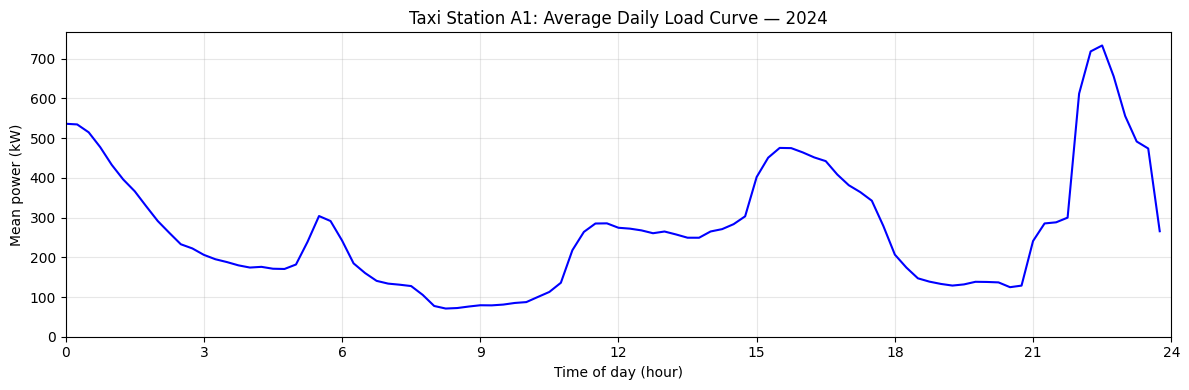

Number of time slots: 96


In [20]:
# Assign each timestamp to a 15-minute slot: 0 through 95
a1_features["slot"] = (
    a1_features["datetime"].dt.hour * 4
    + a1_features["datetime"].dt.minute // 15
)

# Average power across all days for each slot
mean_daily_curve_a1 = (
    a1_features.groupby("slot")["power"].mean()
)

# Convert slots to hours for plotting
hours = mean_daily_curve_a1.index / 4

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(hours, mean_daily_curve_a1.values, color="blue")

ax.set_title("Taxi Station A1: Average Daily Load Curve — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Number of time slots:", len(mean_daily_curve_a1))

In [21]:
# Estimate daily energy from the released interval-average power
daily_metrics_a1["energy_kWh"] = (
    a1_features.groupby("date")["power"].sum() * 0.25
)

display(
    daily_metrics_a1[
        ["average_kW", "peak_kW", "load_factor", "energy_kWh"]
    ].head()
)

# For complete 24-hour days, energy also equals average power × 24
difference = (
    daily_metrics_a1["energy_kWh"]
    - daily_metrics_a1["average_kW"] * 24
).abs()

print("Largest calculation difference:", difference.max())

,average_kW,peak_kW,load_factor,energy_kWh
date,,,,
2024-01-01,344.994792,888.4,0.388333,8279.875
2024-01-02,334.826042,1096.3,0.305415,8035.825
2024-01-03,387.657292,1208.0,0.320908,9303.775
2024-01-04,337.989583,1090.5,0.309940,8111.750
2024-01-05,395.009375,1129.9,0.349597,9480.225


Largest calculation difference: 9.094947017729282e-13


In [22]:
from pathlib import Path
import zipfile

# Save both tables temporarily in Colab
output_folder = Path("/content/A1_results")
output_folder.mkdir(exist_ok=True)

daily_metrics_a1.to_csv(
    output_folder / "A1_daily_metrics_2024.csv",
    index_label="date"
)

mean_daily_curve_a1.rename("mean_power_kW").to_csv(
    output_folder / "A1_mean_daily_curve_2024.csv",
    index_label="slot"
)

# Put both files in one ZIP
zip_path = Path("/content/A1_results.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for file in output_folder.glob("*.csv"):
        archive.write(file, arcname=file.name)

# Download the ZIP to your computer

In [23]:

graph_path = "/content/A1_mean_daily_curve_2024.png"

fig.savefig(graph_path, dpi=300, bbox_inches="tight")


## 3. Station-Level Load Profile Analysis

This section evaluates individual EV charging stations using the 15-minute power profiles.

For each station, the analysis performs:

- Data validation
- Timestamp consistency checks
- Missing value detection
- Daily load curve generation
- Average charging profile calculation
- Station-specific summary statistics

Generated outputs include station-level metrics and daily charging curve figures.

### A1: Taxi Charging Station Load Analysis

- Station A1 is a taxi charging station.
- Source: station-level load Profile 15min.xlsx, sheet A1.
- The original sheet contains 35,232 rows.
- The analysis retains 35,136 intervals covering calendar year 2024.
- The 96 records from January 1, 2025 were excluded from the analysis;
  the original data were preserved.
- No missing values, duplicate timestamps, negative power values,
  missing intervals, or off-schedule timestamps were found.
- All 366 days contain 96 observations.

### Methods
Daily average, peak, valley, peak–valley difference, and load factor
were calculated from the released 15-minute power profiles.

Daily energy was estimated as sum of interval power × 0.25 hours.

The average daily curve was calculated by averaging power at each
15-minute time slot across all 366 days.

### Preliminary observations
The average daily curve shows its largest peak around 22:00–23:00,
another rise around 15:00–17:00, and low load around 08:00–10:00.
These patterns do not establish their causes.

### Saved outputs
- A1_daily_metrics_2024.csv
- A1_mean_daily_curve_2024.csv
- A1_mean_daily_curve_2024.png

In [24]:
# Read station A2
df_a2 = pd.read_excel(workbook, sheet_name="A2")

display(df_a2.head())

print("Rows:", len(df_a2))

print("\nData types:")
print(df_a2.dtypes)

print("\nDate range:")
print("Earliest:", df_a2["datetime"].min())
print("Latest:", df_a2["datetime"].max())

print("\nMissing values:")
print(df_a2.isna().sum())

print("\nDuplicate timestamps:",
      df_a2["datetime"].duplicated().sum())

print("Negative power values:",
      (df_a2["power"] < 0).sum())

,datetime,power
0,2024-01-01 00:00:00,495.2
1,2024-01-01 00:15:00,960.9
2,2024-01-01 00:30:00,1213.5
3,2024-01-01 00:45:00,1318.4
4,2024-01-01 01:00:00,1303.7


Rows: 35232

Data types:
datetime    datetime64[ns]
power              float64
dtype: object

Date range:
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00

Missing values:
datetime    0
power       0
dtype: int64

Duplicate timestamps: 0
Negative power values: 0


In [25]:
# Keep a separate copy of A2's 2024 data
df_a2_2024 = (
    df_a2.loc[
        (df_a2["datetime"] >= "2024-01-01")
        & (df_a2["datetime"] < "2025-01-01")
    ]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

# Build the expected 15-minute schedule
expected_times_a2 = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a2 = pd.DatetimeIndex(df_a2_2024["datetime"])

print("2024 rows:", len(df_a2_2024))
print("Rows outside 2024:", len(df_a2) - len(df_a2_2024))

print("Missing timestamps:",
      len(expected_times_a2.difference(actual_times_a2)))

print("Unexpected timestamps:",
      len(actual_times_a2.difference(expected_times_a2)))

2024 rows: 35136
Rows outside 2024: 96
Missing timestamps: 0
Unexpected timestamps: 0


In [26]:
# Add a date column to a separate working copy
a2_features = df_a2_2024.copy()
a2_features["date"] = a2_features["datetime"].dt.date

# Summarize each day
daily_metrics_a2 = (
    a2_features.groupby("date")
    .agg(
        intervals=("power", "count"),
        average_kW=("power", "mean"),
        peak_kW=("power", "max"),
        valley_kW=("power", "min"),
        power_sum=("power", "sum")
    )
)

daily_metrics_a2["peak_valley_kW"] = (
    daily_metrics_a2["peak_kW"] - daily_metrics_a2["valley_kW"]
)

daily_metrics_a2["load_factor"] = (
    daily_metrics_a2["average_kW"]
    / daily_metrics_a2["peak_kW"].replace(0, float("nan"))
)

# Convert summed interval power into estimated energy
daily_metrics_a2["energy_kWh"] = (
    daily_metrics_a2["power_sum"] * 0.25
)

# Remove the intermediate calculation column
daily_metrics_a2 = daily_metrics_a2.drop(columns="power_sum")

display(daily_metrics_a2.head())

print("Number of days:", len(daily_metrics_a2))
print(
    "Days with 96 intervals:",
    (daily_metrics_a2["intervals"] == 96).sum()
)

,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,799.921875,1655.8,135.6,1520.2,0.483103,19198.125
2024-01-02,96,842.454167,1835.8,64.6,1771.2,0.458903,20218.900
2024-01-03,96,886.976042,2226.8,163.6,2063.2,0.398319,21287.425
2024-01-04,96,902.972917,2007.7,168.1,1839.6,0.449755,21671.350
2024-01-05,96,835.759375,2168.2,111.2,2057.0,0.385462,20058.225


Number of days: 366
Days with 96 intervals: 366


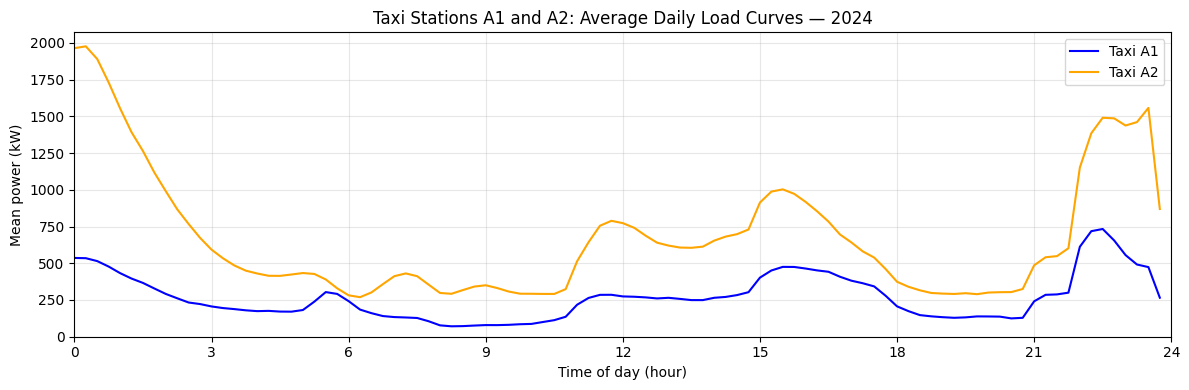

In [27]:
# Assign A2 observations to 15-minute time slots
a2_features["slot"] = (
    a2_features["datetime"].dt.hour * 4
    + a2_features["datetime"].dt.minute // 15
)

# Average A2 power at each slot across all days
mean_daily_curve_a2 = (
    a2_features.groupby("slot")["power"].mean()
)

# Plot both stations on the same axes
fig_comparison, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a1.index / 4,
    mean_daily_curve_a1.values,
    label="Taxi A1",
    color="blue"
)

ax.plot(
    mean_daily_curve_a2.index / 4,
    mean_daily_curve_a2.values,
    label="Taxi A2",
    color="orange"
)

ax.set_title("Taxi Stations A1 and A2: Average Daily Load Curves — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [28]:
# Check which variables exist in the current session
for name in [
    "workbook",
    "df_a1_2024",
    "df_a2_2024",
    "mean_daily_curve_a1",
    "mean_daily_curve_a2"
]:
    print(name, ":", name in globals())

workbook : True
df_a1_2024 : True
df_a2_2024 : True
mean_daily_curve_a1 : True
mean_daily_curve_a2 : True


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

workbook = pd.ExcelFile(workbook_path)

# Define reusable steps for loading one station
def restore_station(station_id):
    data = pd.read_excel(workbook, sheet_name=station_id)

    data_2024 = (
        data.loc[
            (data["datetime"] >= "2024-01-01")
            & (data["datetime"] < "2025-01-01")
        ]
        .copy()
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    data_2024["slot"] = (
        data_2024["datetime"].dt.hour * 4
        + data_2024["datetime"].dt.minute // 15
    )

    mean_curve = data_2024.groupby("slot")["power"].mean()

    return data_2024, mean_curve


# Apply the function to both taxi stations
df_a1_2024, mean_daily_curve_a1 = restore_station("A1")
df_a2_2024, mean_daily_curve_a2 = restore_station("A2")

print("A1 rows:", len(df_a1_2024))
print("A2 rows:", len(df_a2_2024))
print("A1 curve points:", len(mean_daily_curve_a1))
print("A2 curve points:", len(mean_daily_curve_a2))

A1 rows: 35136
A2 rows: 35136
A1 curve points: 96
A2 curve points: 96


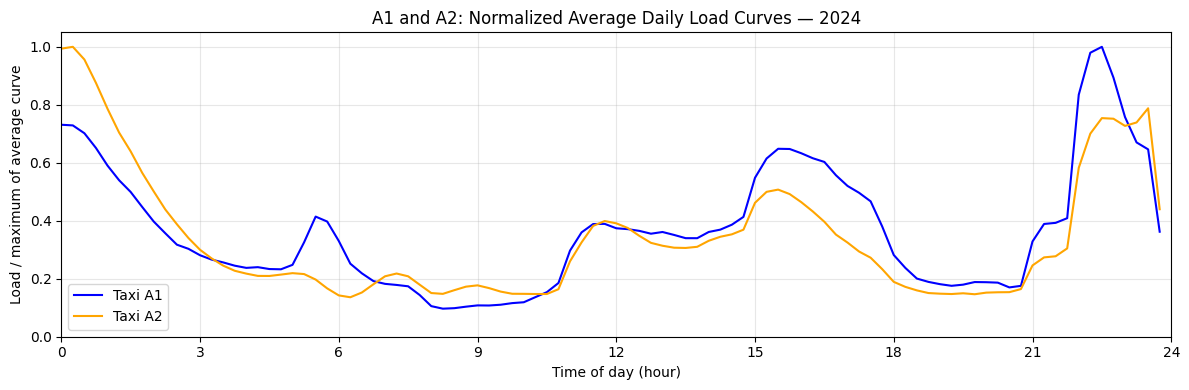

In [30]:
normalized_a1 = mean_daily_curve_a1 / mean_daily_curve_a1.max()
normalized_a2 = mean_daily_curve_a2 / mean_daily_curve_a2.max()

fig_normalized, ax = plt.subplots(figsize=(12, 4))

ax.plot(normalized_a1.index / 4, normalized_a1,
        label="Taxi A1", color="blue")

ax.plot(normalized_a2.index / 4, normalized_a2,
        label="Taxi A2", color="orange")

ax.set_title("A1 and A2: Normalized Average Daily Load Curves — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Load / maximum of average curve")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
# Find the slot with the highest average power
peak_slot_a1 = int(mean_daily_curve_a1.idxmax())
peak_slot_a2 = int(mean_daily_curve_a2.idxmax())

# Convert a slot number into HH:MM
def slot_to_time(slot):
    hour = slot // 4
    minute = (slot % 4) * 15
    return f"{hour:02d}:{minute:02d}"

print(
    "A1 average-curve peak:",
    slot_to_time(peak_slot_a1),
    f"— {mean_daily_curve_a1.max():.2f} kW"
)

print(
    "A2 average-curve peak:",
    slot_to_time(peak_slot_a2),
    f"— {mean_daily_curve_a2.max():.2f} kW"
)

A1 average-curve peak: 22:30 — 733.36 kW
A2 average-curve peak: 00:15 — 1976.73 kW


In [32]:
from pathlib import Path
import zipfile

save_folder = Path("/content/taxi_comparison")
save_folder.mkdir(exist_ok=True)

# Save the graph using its specific figure variable
fig_normalized.savefig(
    save_folder / "A1_A2_normalized_curves.png",
    dpi=300,
    bbox_inches="tight"
)

# Put the original and normalized curves in one table
comparison_table = pd.DataFrame({
    "A1_mean_power_kW": mean_daily_curve_a1,
    "A2_mean_power_kW": mean_daily_curve_a2,
    "A1_normalized": normalized_a1,
    "A2_normalized": normalized_a2
})

comparison_table.to_csv(
    save_folder / "A1_A2_average_curves.csv",
    index_label="slot"
)

# Package and download both files
download_path = Path("/content/taxi_comparison.zip")

with zipfile.ZipFile(
    download_path, "w", zipfile.ZIP_DEFLATED
) as archive:
    for file in save_folder.iterdir():
        if file.is_file():
            archive.write(file, arcname=file.name)

In [33]:
# Open the original A3 sheet
df_a3 = pd.read_excel(workbook, sheet_name="A3")

display(df_a3.head())

print("Rows:", len(df_a3))

print("\nData types:")
print(df_a3.dtypes)

print("\nDate range:")
print("Earliest:", df_a3["datetime"].min())
print("Latest:", df_a3["datetime"].max())

print("\nMissing values:")
print(df_a3.isna().sum())

print("\nDuplicate timestamps:",
      df_a3["datetime"].duplicated().sum())

print("Negative power values:",
      (df_a3["power"] < 0).sum())

,datetime,power
0,2024-01-01 00:00:00,424.3
1,2024-01-01 00:15:00,778.5
2,2024-01-01 00:30:00,932.2
3,2024-01-01 00:45:00,1214.3
4,2024-01-01 01:00:00,1721.4


Rows: 35232

Data types:
datetime    datetime64[ns]
power              float64
dtype: object

Date range:
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00

Missing values:
datetime    0
power       0
dtype: int64

Duplicate timestamps: 0
Negative power values: 0


In [34]:
# Reuse the function you defined for A1 and A2
df_a3_2024, mean_daily_curve_a3 = restore_station("A3")

# Check every expected timestamp is present
expected_times_a3 = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a3 = pd.DatetimeIndex(df_a3_2024["datetime"])

print("2024 rows:", len(df_a3_2024))
print("Rows outside 2024:", len(df_a3) - len(df_a3_2024))
print("Average-curve points:", len(mean_daily_curve_a3))

print("Missing timestamps:",
      len(expected_times_a3.difference(actual_times_a3)))

print("Unexpected timestamps:",
      len(actual_times_a3.difference(expected_times_a3)))

2024 rows: 35136
Rows outside 2024: 96
Average-curve points: 96
Missing timestamps: 0
Unexpected timestamps: 0


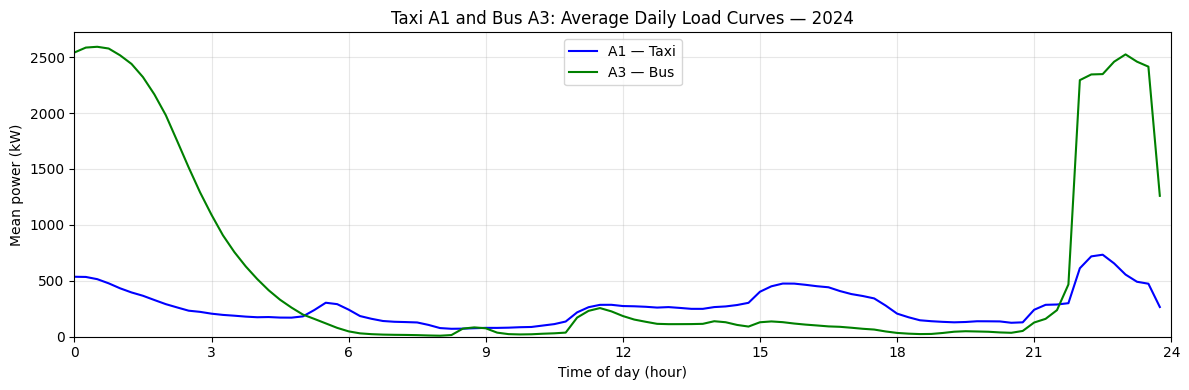

In [35]:
fig_taxi_bus, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a1.index / 4,
    mean_daily_curve_a1.values,
    label="A1 — Taxi",
    color="blue"
)

ax.plot(
    mean_daily_curve_a3.index / 4,
    mean_daily_curve_a3.values,
    label="A3 — Bus",
    color="green"
)

ax.set_title("Taxi A1 and Bus A3: Average Daily Load Curves — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [36]:
# Calculate the share of yearly energy occurring from 22:00 to 06:00
def night_energy_share(data):
    hours = data["datetime"].dt.hour

    # | means OR: after 22:00 OR before 06:00
    night_mask = (hours >= 22) | (hours < 6)

    night_energy = data.loc[night_mask, "power"].sum() * 0.25
    total_energy = data["power"].sum() * 0.25

    return night_energy / total_energy if total_energy > 0 else float("nan")


night_share_a1 = night_energy_share(df_a1_2024)
night_share_a3 = night_energy_share(df_a3_2024)

print(f"A1 taxi — nighttime energy share: {night_share_a1:.1%}")
print(f"A3 bus — nighttime energy share: {night_share_a3:.1%}")

A1 taxi — nighttime energy share: 44.7%
A3 bus — nighttime energy share: 89.8%


In [37]:
# Read the original A4 sheet
df_a4 = pd.read_excel(workbook, sheet_name="A4")

display(df_a4.head())

print("Rows:", len(df_a4))

print("\nData types:")
print(df_a4.dtypes)

print("\nDate range:")
print("Earliest:", df_a4["datetime"].min())
print("Latest:", df_a4["datetime"].max())

print("\nMissing values:")
print(df_a4.isna().sum())

print("\nDuplicate timestamps:",
      df_a4["datetime"].duplicated().sum())

print("Negative power values:",
      (df_a4["power"] < 0).sum())

,datetime,power
0,2024-01-01 00:00:00,2447.8
1,2024-01-01 00:15:00,3644.2
2,2024-01-01 00:30:00,4355.9
3,2024-01-01 00:45:00,5296.1
4,2024-01-01 01:00:00,5291.6


Rows: 35232

Data types:
datetime    datetime64[ns]
power              float64
dtype: object

Date range:
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00

Missing values:
datetime    0
power       0
dtype: int64

Duplicate timestamps: 0
Negative power values: 0


In [38]:
# Select 2024 and build the average daily curve
df_a4_2024, mean_daily_curve_a4 = restore_station("A4")

# Check time coverage
expected_times_a4 = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a4 = pd.DatetimeIndex(df_a4_2024["datetime"])

print("2024 rows:", len(df_a4_2024))
print("Missing timestamps:",
      len(expected_times_a4.difference(actual_times_a4)))
print("Unexpected timestamps:",
      len(actual_times_a4.difference(expected_times_a4)))

# Compare nighttime concentration in the two bus stations
night_share_a4 = night_energy_share(df_a4_2024)

print(f"\nA3 nighttime energy share: {night_share_a3:.1%}")
print(f"A4 nighttime energy share: {night_share_a4:.1%}")

2024 rows: 35136
Missing timestamps: 0
Unexpected timestamps: 0

A3 nighttime energy share: 89.8%
A4 nighttime energy share: 95.2%


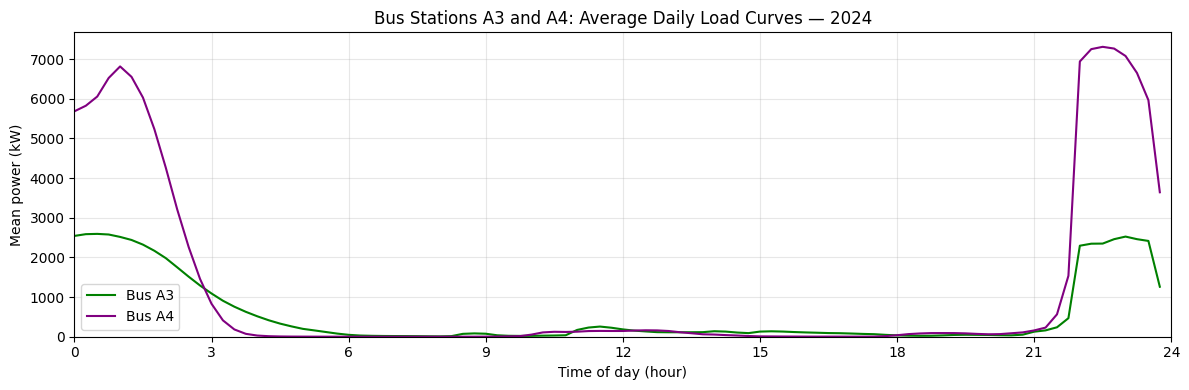

In [39]:
fig_bus_comparison, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a3.index / 4,
    mean_daily_curve_a3.values,
    label="Bus A3",
    color="green"
)

ax.plot(
    mean_daily_curve_a4.index / 4,
    mean_daily_curve_a4.values,
    label="Bus A4",
    color="purple"
)

ax.set_title("Bus Stations A3 and A4: Average Daily Load Curves — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [40]:
from pathlib import Path
import zipfile

bus_folder = Path("/content/bus_comparison")
bus_folder.mkdir(exist_ok=True)

# Save the graph
fig_bus_comparison.savefig(
    bus_folder / "A3_A4_average_curves.png",
    dpi=300,
    bbox_inches="tight"
)

# Save both average curves
pd.DataFrame({
    "A3_mean_power_kW": mean_daily_curve_a3,
    "A4_mean_power_kW": mean_daily_curve_a4
}).to_csv(
    bus_folder / "A3_A4_average_curves.csv",
    index_label="slot"
)

# Save nighttime energy shares
pd.DataFrame({
    "station": ["A3", "A4"],
    "night_period": ["22:00–06:00", "22:00–06:00"],
    "night_energy_share": [night_share_a3, night_share_a4]
}).to_csv(
    bus_folder / "A3_A4_night_energy_shares.csv",
    index=False
)

# Package the three files
bus_zip = Path("/content/bus_comparison.zip")

with zipfile.ZipFile(bus_zip, "w", zipfile.ZIP_DEFLATED) as archive:
    for file in bus_folder.iterdir():
        if file.is_file():
            archive.write(file, arcname=file.name)

In [41]:
def calculate_daily_metrics(data):
    # Work on a copy so the input table stays unchanged
    working = data.copy()
    working["date"] = working["datetime"].dt.date

    # Summarize each day's observations
    daily = working.groupby("date").agg(
        intervals=("power", "count"),
        average_kW=("power", "mean"),
        peak_kW=("power", "max"),
        valley_kW=("power", "min"),
        power_sum=("power", "sum")
    )

    # Only calculate daily metrics for complete days
    daily = daily.loc[daily["intervals"] == 96].copy()

    daily["peak_valley_kW"] = (
        daily["peak_kW"] - daily["valley_kW"]
    )

    daily["load_factor"] = (
        daily["average_kW"]
        / daily["peak_kW"].replace(0, float("nan"))
    )

    daily["energy_kWh"] = daily["power_sum"] * 0.25

    return daily.drop(columns="power_sum")


# Apply the function to both bus stations
daily_metrics_a3 = calculate_daily_metrics(df_a3_2024)
daily_metrics_a4 = calculate_daily_metrics(df_a4_2024)

print("A3 daily metrics:")
display(daily_metrics_a3.head())

print("A4 daily metrics:")
display(daily_metrics_a4.head())

print("Complete A3 days:", len(daily_metrics_a3))
print("Complete A4 days:", len(daily_metrics_a4))

A3 daily metrics:


,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,648.438542,2683.7,0.0,2683.7,0.241621,15562.525
2024-01-02,96,792.300000,2788.5,0.0,2788.5,0.284131,19015.200
2024-01-03,96,878.877083,2902.4,0.0,2902.4,0.302810,21093.050
2024-01-04,96,902.222917,2786.1,0.0,2786.1,0.323830,21653.350
2024-01-05,96,815.155208,3194.1,0.0,3194.1,0.255207,19563.725


A4 daily metrics:


,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,1164.652083,7227.5,0.0,7227.5,0.161142,27951.650
2024-01-02,96,1410.513542,8325.8,0.0,8325.8,0.169415,33852.325
2024-01-03,96,1519.235417,8257.6,0.0,8257.6,0.183980,36461.650
2024-01-04,96,1576.421875,8502.9,0.0,8502.9,0.185398,37834.125
2024-01-05,96,1522.423958,8244.7,0.0,8244.7,0.184655,36538.175


Complete A3 days: 366
Complete A4 days: 366


In [42]:
for station, daily in [
    ("A3", daily_metrics_a3),
    ("A4", daily_metrics_a4)
]:
    energy_difference = (
        daily["energy_kWh"] - daily["average_kW"] * 24
    ).abs().max()

    print(f"{station}:")
    print("Complete days:", len(daily))
    print("All days have 96 intervals:",
          daily["intervals"].eq(96).all())
    print("Largest energy calculation difference:",
          energy_difference)
    print()

A3:
Complete days: 366
All days have 96 intervals: True
Largest energy calculation difference: 3.637978807091713e-12

A4:
Complete days: 366
All days have 96 intervals: True
Largest energy calculation difference: 3.637978807091713e-12



In [43]:
df_a5 = pd.read_excel(workbook, sheet_name="A5")

display(df_a5.head())

print("Rows:", len(df_a5))

print("\nData types:")
print(df_a5.dtypes)

print("\nDate range:")
print("Earliest:", df_a5["datetime"].min())
print("Latest:", df_a5["datetime"].max())

print("\nMissing values:")
print(df_a5.isna().sum())

print("\nDuplicate timestamps:",
      df_a5["datetime"].duplicated().sum())

print("Negative power values:",
      (df_a5["power"] < 0).sum())

,datetime,power
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:15:00,0.0
2,2024-01-01 00:30:00,0.0
3,2024-01-01 00:45:00,0.0
4,2024-01-01 01:00:00,0.0


Rows: 35232

Data types:
datetime    datetime64[ns]
power              float64
dtype: object

Date range:
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00

Missing values:
datetime    0
power       0
dtype: int64

Duplicate timestamps: 0
Negative power values: 0


In [44]:
# Prepare residential station A5 using your existing function
df_a5_2024, mean_daily_curve_a5 = restore_station("A5")

expected_times_a5 = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a5 = pd.DatetimeIndex(df_a5_2024["datetime"])

print("2024 rows:", len(df_a5_2024))
print("Missing timestamps:",
      len(expected_times_a5.difference(actual_times_a5)))
print("Unexpected timestamps:",
      len(actual_times_a5.difference(expected_times_a5)))

2024 rows: 35136
Missing timestamps: 0
Unexpected timestamps: 0


,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,8.493750,27.3,0.0,27.3,0.311126,203.850
2024-01-02,96,5.964583,21.8,0.0,21.8,0.273605,143.150
2024-01-03,96,5.912500,21.3,0.0,21.3,0.277582,141.900
2024-01-04,96,6.203125,21.3,0.0,21.3,0.291227,148.875
2024-01-05,96,7.538542,31.6,0.0,31.6,0.238561,180.925


Complete days: 366
Nighttime energy share: 63.6%


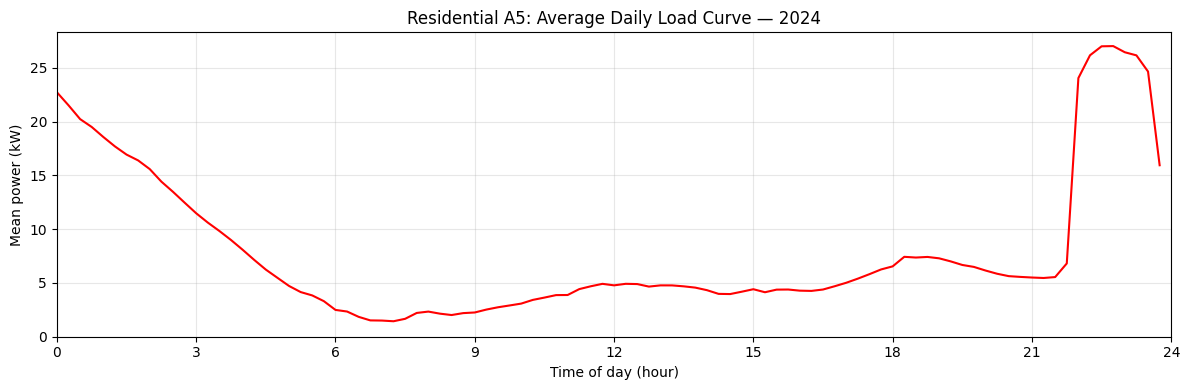

,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,8.493750,27.3,0.0,27.3,0.311126,203.850
2024-01-02,96,5.964583,21.8,0.0,21.8,0.273605,143.150
2024-01-03,96,5.912500,21.3,0.0,21.3,0.277582,141.900
2024-01-04,96,6.203125,21.3,0.0,21.3,0.291227,148.875
2024-01-05,96,7.538542,31.6,0.0,31.6,0.238561,180.925


Complete days: 366
Nighttime energy share: 63.6%


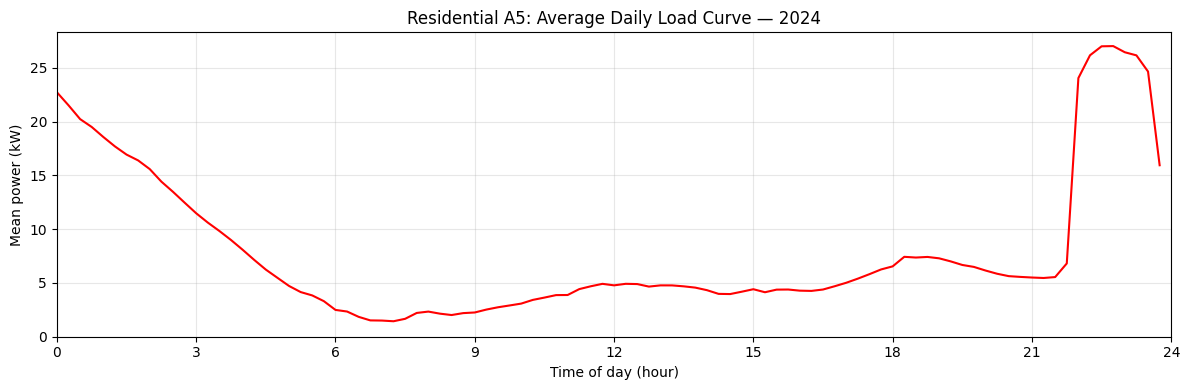

In [45]:
# Calculate daily features
daily_metrics_a5 = calculate_daily_metrics(df_a5_2024)

display(daily_metrics_a5.head())
print("Complete days:", len(daily_metrics_a5))

# Calculate energy share during 22:00–06:00
night_share_a5 = night_energy_share(df_a5_2024)
print(f"Nighttime energy share: {night_share_a5:.1%}")

# Plot A5's average daily curve
fig_a5, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a5.index / 4,
    mean_daily_curve_a5.values,
    color="red"
)

ax.set_title("Residential A5: Average Daily Load Curve — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()# Calculate daily features
daily_metrics_a5 = calculate_daily_metrics(df_a5_2024)

display(daily_metrics_a5.head())
print("Complete days:", len(daily_metrics_a5))

# Calculate energy share during 22:00–06:00
night_share_a5 = night_energy_share(df_a5_2024)
print(f"Nighttime energy share: {night_share_a5:.1%}")

# Plot A5's average daily curve
fig_a5, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a5.index / 4,
    mean_daily_curve_a5.values,
    color="red"
)

ax.set_title("Residential A5: Average Daily Load Curve — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
df_a6 = pd.read_excel(workbook, sheet_name="A6")

display(df_a6.head())

print("Rows:", len(df_a6))

print("\nData types:")
print(df_a6.dtypes)

print("\nDate range:")
print("Earliest:", df_a6["datetime"].min())
print("Latest:", df_a6["datetime"].max())

print("\nMissing values:")
print(df_a6.isna().sum())

print("\nDuplicate timestamps:",
      df_a6["datetime"].duplicated().sum())

print("Negative power values:",
      (df_a6["power"] < 0).sum())

,datetime,power
0,2024-01-01 00:00:00,0.0
1,2024-01-01 00:15:00,0.0
2,2024-01-01 00:30:00,0.0
3,2024-01-01 00:45:00,0.0
4,2024-01-01 01:00:00,1.0


Rows: 35232

Data types:
datetime    datetime64[ns]
power              float64
dtype: object

Date range:
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00

Missing values:
datetime    0
power       0
dtype: int64

Duplicate timestamps: 0
Negative power values: 0


In [47]:
# Prepare A6 using your existing function
df_a6_2024, mean_daily_curve_a6 = restore_station("A6")

# Check the expected 2024 time schedule
expected_times_a6 = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a6 = pd.DatetimeIndex(df_a6_2024["datetime"])

print("2024 rows:", len(df_a6_2024))
print("Missing timestamps:",
      len(expected_times_a6.difference(actual_times_a6)))
print("Unexpected timestamps:",
      len(actual_times_a6.difference(expected_times_a6)))

# Build daily features and calculate nighttime concentration
daily_metrics_a6 = calculate_daily_metrics(df_a6_2024)

display(daily_metrics_a6.head())
print("Complete days:", len(daily_metrics_a6))

night_share_a6 = night_energy_share(df_a6_2024)
print(f"\nA5 nighttime energy share: {night_share_a5:.1%}")
print(f"A6 nighttime energy share: {night_share_a6:.1%}")

2024 rows: 35136
Missing timestamps: 0
Unexpected timestamps: 0


,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,17.685417,67.1,0.0,67.1,0.263568,424.450
2024-01-02,96,24.881250,69.2,0.0,69.2,0.359556,597.150
2024-01-03,96,18.500000,55.6,0.0,55.6,0.332734,444.000
2024-01-04,96,24.927083,64.0,0.7,63.3,0.389486,598.250
2024-01-05,96,24.465625,61.2,6.1,55.1,0.399765,587.175


Complete days: 366

A5 nighttime energy share: 63.6%
A6 nighttime energy share: 46.5%


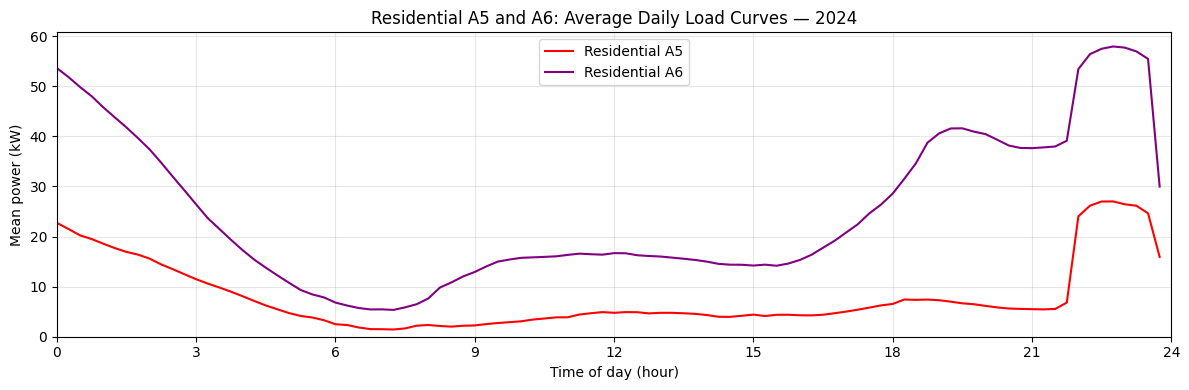

In [48]:
fig_residential, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a5.index / 4,
    mean_daily_curve_a5.values,
    label="Residential A5",
    color="red"
)

ax.plot(
    mean_daily_curve_a6.index / 4,
    mean_daily_curve_a6.values,
    label="Residential A6",
    color="purple"
)

ax.set_title("Residential A5 and A6: Average Daily Load Curves — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [49]:
from pathlib import Path
from google.colab import files
import zipfile

folder = Path("/content/residential_results")
folder.mkdir(exist_ok=True)

# Save daily features
daily_metrics_a5.to_csv(
    folder / "A5_daily_metrics_2024.csv",
    index_label="date"
)

daily_metrics_a6.to_csv(
    folder / "A6_daily_metrics_2024.csv",
    index_label="date"
)

# Save average curves
pd.DataFrame({
    "A5_mean_power_kW": mean_daily_curve_a5,
    "A6_mean_power_kW": mean_daily_curve_a6
}).to_csv(
    folder / "A5_A6_average_curves.csv",
    index_label="slot"
)

# Save nighttime shares
pd.DataFrame({
    "station": ["A5", "A6"],
    "night_period": ["22:00-06:00", "22:00-06:00"],
    "night_energy_share": [night_share_a5, night_share_a6]
}).to_csv(folder / "night_energy_shares.csv", index=False)

# Save the comparison graph
fig_residential.savefig(
    folder / "A5_A6_average_curves.png",
    dpi=300,
    bbox_inches="tight"
)

# Package and download
residential_zip = Path("/content/residential_results.zip")

with zipfile.ZipFile(
    residential_zip, "w", zipfile.ZIP_DEFLATED
) as archive:
    for file in folder.iterdir():
        if file.is_file():
            archive.write(file, arcname=file.name)

files.download(str(residential_zip))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
# Read the original A7 profile
df_a7 = pd.read_excel(workbook, sheet_name="A7")

display(df_a7.head())

print("Rows:", len(df_a7))

print("\nData types:")
print(df_a7.dtypes)

print("\nDate range:")
print("Earliest:", df_a7["datetime"].min())
print("Latest:", df_a7["datetime"].max())

print("\nMissing values:")
print(df_a7.isna().sum())

print("\nDuplicate timestamps:",
      df_a7["datetime"].duplicated().sum())

print("Negative session counts:",
      (df_a7["session_count"] < 0).sum())

print("Non-integer session counts:",
      (df_a7["session_count"].dropna() % 1 != 0).sum())

print("Largest interval count:",
      df_a7["session_count"].max())

,datetime,session_count
0,2024-01-01 00:00:00,0
1,2024-01-01 00:15:00,0
2,2024-01-01 00:30:00,0
3,2024-01-01 00:45:00,0
4,2024-01-01 01:00:00,0


Rows: 35328

Data types:
datetime         datetime64[ns]
session_count             int64
dtype: object

Date range:
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-02 23:45:00

Missing values:
datetime         0
session_count    0
dtype: int64

Duplicate timestamps: 0
Negative session counts: 0
Non-integer session counts: 0
Largest interval count: 256


In [51]:
# Keep calendar 2024, preserving the original table
df_a7_2024 = (
    df_a7.loc[
        (df_a7["datetime"] >= "2024-01-01")
        & (df_a7["datetime"] < "2025-01-01")
    ]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

# Check the complete 15-minute schedule
expected_times_a7 = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a7 = pd.DatetimeIndex(df_a7_2024["datetime"])

print("2024 rows:", len(df_a7_2024))
print("Rows outside 2024:", len(df_a7) - len(df_a7_2024))
print("Missing timestamps:",
      len(expected_times_a7.difference(actual_times_a7)))
print("Unexpected timestamps:",
      len(actual_times_a7.difference(expected_times_a7)))

# Inspect the five largest interval counts
print("\nLargest counts in 2024:")
display(df_a7_2024.nlargest(5, "session_count"))

2024 rows: 35136
Rows outside 2024: 192
Missing timestamps: 0
Unexpected timestamps: 0

Largest counts in 2024:


,datetime,session_count
19913,2024-07-26 10:15:00,256
24538,2024-09-12 14:30:00,22
34035,2024-12-20 12:45:00,20
15450,2024-06-09 22:30:00,19
15642,2024-06-11 22:30:00,18


In [52]:
# Locate the largest count
largest_index = df_a7_2024["session_count"].idxmax()
spike_time = df_a7_2024.loc[largest_index, "datetime"]

# Show one hour before and after it
near_spike = df_a7_2024.loc[
    (df_a7_2024["datetime"] >= spike_time - pd.Timedelta(hours=1))
    & (df_a7_2024["datetime"] <= spike_time + pd.Timedelta(hours=1))
]

print("Intervals around the unusually large count:")
display(near_spike)

# Examine the overall count distribution
print("\nCount distribution:")
print(
    df_a7_2024["session_count"].describe(
        percentiles=[0.5, 0.95, 0.99]
    )
)

Intervals around the unusually large count:


,datetime,session_count
19909,2024-07-26 09:15:00,1
19910,2024-07-26 09:30:00,1
19911,2024-07-26 09:45:00,0
19912,2024-07-26 10:00:00,0
19913,2024-07-26 10:15:00,256
19914,2024-07-26 10:30:00,3
19915,2024-07-26 10:45:00,0
19916,2024-07-26 11:00:00,1
19917,2024-07-26 11:15:00,1



Count distribution:
count    35136.000000
mean         3.353996
std          2.872139
min          0.000000
50%          3.000000
95%          8.000000
99%         11.000000
max        256.000000
Name: session_count, dtype: float64


In [53]:
a7_features = df_a7_2024.copy()
a7_features["date"] = a7_features["datetime"].dt.date

# Flag the observation we investigated
a7_features["flagged_spike"] = (
    a7_features["datetime"] == spike_time
)

daily_metrics_a7 = a7_features.groupby("date").agg(
    intervals=("session_count", "count"),
    average_count=("session_count", "mean"),
    peak_count=("session_count", "max"),
    valley_count=("session_count", "min"),
    total_count=("session_count", "sum"),
    flagged_intervals=("flagged_spike", "sum")
)

# Retain complete days
daily_metrics_a7 = daily_metrics_a7.loc[
    daily_metrics_a7["intervals"] == 96
].copy()

daily_metrics_a7["peak_valley_count"] = (
    daily_metrics_a7["peak_count"]
    - daily_metrics_a7["valley_count"]
)

daily_metrics_a7["activity_factor"] = (
    daily_metrics_a7["average_count"]
    / daily_metrics_a7["peak_count"].replace(0, float("nan"))
)

display(daily_metrics_a7.head())

print("Complete days:", len(daily_metrics_a7))

print("\nDay containing the flagged spike:")
display(
    daily_metrics_a7.loc[
        daily_metrics_a7["flagged_intervals"] > 0
    ]
)

,intervals,average_count,peak_count,valley_count,total_count,flagged_intervals,peak_valley_count,activity_factor
date,,,,,,,,
2024-01-01,96,3.635417,12,0,349,0,12,0.302951
2024-01-02,96,4.010417,10,0,385,0,10,0.401042
2024-01-03,96,4.083333,11,0,392,0,11,0.371212
2024-01-04,96,4.166667,13,0,400,0,13,0.320513
2024-01-05,96,4.166667,13,0,400,0,13,0.320513


Complete days: 366

Day containing the flagged spike:


,intervals,average_count,peak_count,valley_count,total_count,flagged_intervals,peak_valley_count,activity_factor
date,,,,,,,,
2024-07-26,96,4.989583,256,0,479,1,256,0.019491


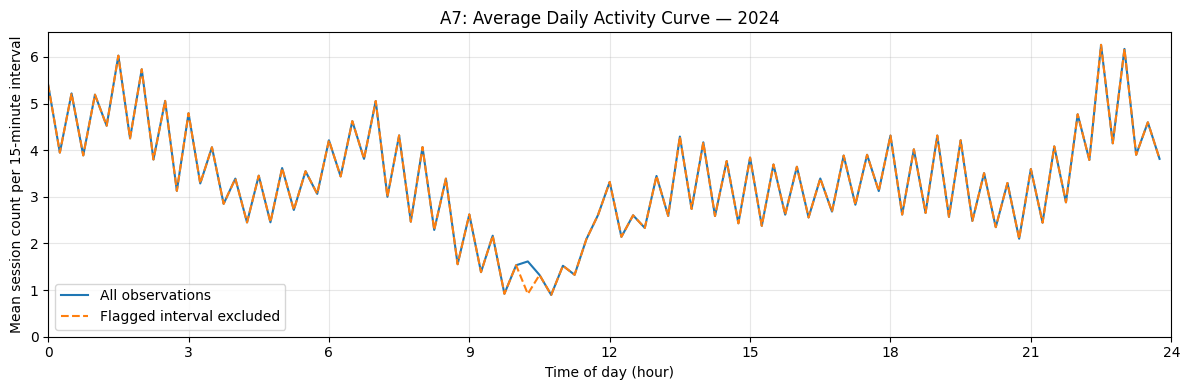

In [54]:
# Create time-of-day slots
a7_features["slot"] = (
    a7_features["datetime"].dt.hour * 4
    + a7_features["datetime"].dt.minute // 15
)

# Main result: retain every observation
mean_daily_curve_a7 = (
    a7_features.groupby("slot")["session_count"].mean()
)

# Sensitivity result: exclude only the flagged interval
mean_curve_a7_without_spike = (
    a7_features.loc[~a7_features["flagged_spike"]]
    .groupby("slot")["session_count"].mean()
)

fig_a7, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_daily_curve_a7.index / 4,
    mean_daily_curve_a7.values,
    label="All observations"
)

ax.plot(
    mean_curve_a7_without_spike.index / 4,
    mean_curve_a7_without_spike.values,
    label="Flagged interval excluded",
    linestyle="--"
)

ax.set_title("A7: Average Daily Activity Curve — 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean session count per 15-minute interval")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [55]:
df_a8 = pd.read_excel(workbook, sheet_name="A8")

display(df_a8.head())

print("Rows:", len(df_a8))

print("\nData types:")
print(df_a8.dtypes)

print("\nDate range:")
print("Earliest:", df_a8["datetime"].min())
print("Latest:", df_a8["datetime"].max())

print("\nMissing values:")
print(df_a8.isna().sum())

print("\nDuplicate timestamps:",
      df_a8["datetime"].duplicated().sum())

print("Negative counts:",
      (df_a8["session_count"] < 0).sum())

print("Non-integer counts:",
      (df_a8["session_count"].dropna() % 1 != 0).sum())

print("\nLargest interval counts:")
display(df_a8.nlargest(5, "session_count"))

,datetime,session_count
0,2024-01-26 00:00:00,0
1,2024-01-26 00:15:00,0
2,2024-01-26 00:30:00,0
3,2024-01-26 00:45:00,0
4,2024-01-26 01:00:00,0


Rows: 32832

Data types:
datetime         datetime64[ns]
session_count             int64
dtype: object

Date range:
Earliest: 2024-01-26 00:00:00
Latest: 2025-01-01 23:45:00

Missing values:
datetime         0
session_count    0
dtype: int64

Duplicate timestamps: 0
Negative counts: 0
Non-integer counts: 0

Largest interval counts:


,datetime,session_count
132,2024-01-27 09:00:00,3
246,2024-01-28 13:30:00,3
448,2024-01-30 16:00:00,3
546,2024-01-31 16:30:00,3
653,2024-02-01 19:15:00,3


In [56]:
# Retain A8's observations within calendar 2024
df_a8_2024 = (
    df_a8.loc[
        (df_a8["datetime"] >= "2024-01-01")
        & (df_a8["datetime"] < "2025-01-01")
    ]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

# Check completeness within its supplied 2024 coverage
expected_times_a8 = pd.date_range(
    start="2024-01-26 00:00:00",
    end="2024-12-31 23:45:00",
    freq="15min"
)

actual_times_a8 = pd.DatetimeIndex(df_a8_2024["datetime"])

print("2024 rows:", len(df_a8_2024))
print("Rows outside 2024:", len(df_a8) - len(df_a8_2024))
print("Missing timestamps within coverage:",
      len(expected_times_a8.difference(actual_times_a8)))
print("Unexpected timestamps:",
      len(actual_times_a8.difference(expected_times_a8)))

2024 rows: 32736
Rows outside 2024: 96
Missing timestamps within coverage: 0
Unexpected timestamps: 0


In [57]:
a8_features = df_a8_2024.copy()
a8_features["date"] = a8_features["datetime"].dt.date

daily_metrics_a8 = a8_features.groupby("date").agg(
    intervals=("session_count", "count"),
    average_count=("session_count", "mean"),
    peak_count=("session_count", "max"),
    valley_count=("session_count", "min"),
    total_count=("session_count", "sum")
)

# Keep complete days
daily_metrics_a8 = daily_metrics_a8.loc[
    daily_metrics_a8["intervals"] == 96
].copy()

daily_metrics_a8["peak_valley_count"] = (
    daily_metrics_a8["peak_count"]
    - daily_metrics_a8["valley_count"]
)

daily_metrics_a8["activity_factor"] = (
    daily_metrics_a8["average_count"]
    / daily_metrics_a8["peak_count"].replace(0, float("nan"))
)

display(daily_metrics_a8.head())

print("Complete days:", len(daily_metrics_a8))
print("Total recorded count:", daily_metrics_a8["total_count"].sum())
print("Zero-activity days:",
      daily_metrics_a8["total_count"].eq(0).sum())

,intervals,average_count,peak_count,valley_count,total_count,peak_valley_count,activity_factor
date,,,,,,,
2024-01-26,96,0.208333,2,0,20,2,0.104167
2024-01-27,96,0.500000,3,0,48,3,0.166667
2024-01-28,96,0.458333,3,0,44,3,0.152778
2024-01-29,96,0.270833,1,0,26,1,0.270833
2024-01-30,96,0.218750,3,0,21,3,0.072917


Complete days: 341
Total recorded count: 8211
Zero-activity days: 31


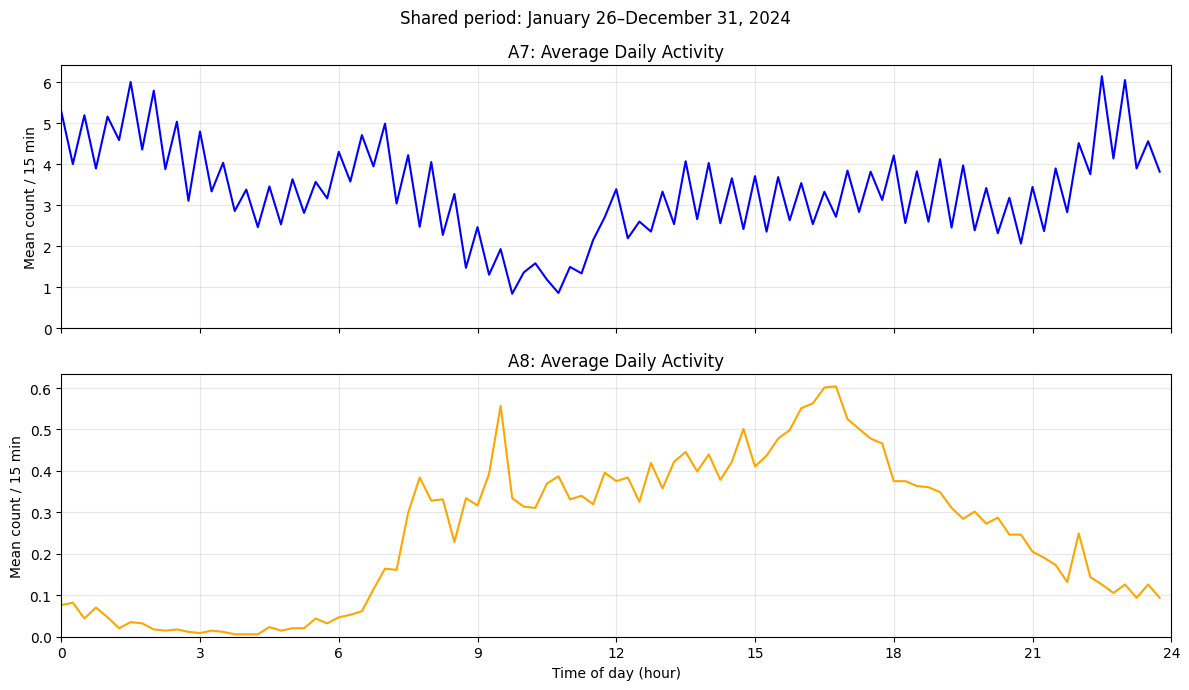

In [58]:
# Restrict A7 to A8's observation period
a7_shared = df_a7_2024.loc[
    df_a7_2024["datetime"] >= "2024-01-26"
].copy()

a8_shared = df_a8_2024.copy()

# Reusable function for averaging count profiles by time slot
def average_activity_curve(data):
    working = data.copy()

    working["slot"] = (
        working["datetime"].dt.hour * 4
        + working["datetime"].dt.minute // 15
    )

    return working.groupby("slot")["session_count"].mean()


mean_curve_a7_shared = average_activity_curve(a7_shared)
mean_curve_a8_shared = average_activity_curve(a8_shared)

fig_swap, axes = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True
)

for ax, curve, station, color in [
    (axes[0], mean_curve_a7_shared, "A7", "blue"),
    (axes[1], mean_curve_a8_shared, "A8", "orange")
]:
    ax.plot(curve.index / 4, curve.values, color=color)
    ax.set_title(f"{station}: Average Daily Activity")
    ax.set_ylabel("Mean count / 15 min")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Time of day (hour)")
axes[1].set_xticks(range(0, 25, 3))
axes[1].set_xlim(0, 24)

fig_swap.suptitle("Shared period: January 26–December 31, 2024")
plt.tight_layout()
plt.show()

In [59]:
from pathlib import Path
import zipfile

folder = Path("/content/battery_swap_results")
folder.mkdir(exist_ok=True)

# Daily tables cover each station's own 2024 observation period
daily_metrics_a7.to_csv(
    folder / "A7_daily_activity_2024.csv",
    index_label="date"
)

daily_metrics_a8.to_csv(
    folder / "A8_daily_activity_2024.csv",
    index_label="date"
)

# Average curves cover the matched January 26–December 31 period
pd.DataFrame({
    "A7_mean_count": mean_curve_a7_shared,
    "A8_mean_count": mean_curve_a8_shared
}).to_csv(
    folder / "A7_A8_shared_period_curves.csv",
    index_label="slot"
)

# Preserve the flagged observation
a7_features.loc[a7_features["flagged_spike"]].to_csv(
    folder / "A7_flagged_observation.csv",
    index=False
)

# Save both figures
fig_swap.savefig(
    folder / "A7_A8_shared_period_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

fig_a7.savefig(
    folder / "A7_spike_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

# Package and download
swap_zip = Path("/content/battery_swap_results.zip")

with zipfile.ZipFile(swap_zip, "w", zipfile.ZIP_DEFLATED) as archive:
    for file in folder.iterdir():
        if file.is_file():
            archive.write(file, arcname=file.name)

In [60]:
# Store the original truck-station tables
truck_data = {}

for station in ["A9", "A10"]:
    data = pd.read_excel(workbook, sheet_name=station)
    truck_data[station] = data

    print(f"\n--- {station}: Truck station ---")
    display(data.head())

    print("Rows:", len(data))
    print("Data types:")
    print(data.dtypes)

    print("Earliest:", data["datetime"].min())
    print("Latest:", data["datetime"].max())

    print("Missing values:")
    print(data.isna().sum())

    print("Duplicate timestamps:",
          data["datetime"].duplicated().sum())

    print("Negative power values:",
          (data["power"] < 0).sum())


--- A9: Truck station ---


,datetime,power
0,2024-01-01 00:00:00,294.4
1,2024-01-01 00:15:00,432.7
2,2024-01-01 00:30:00,720.1
3,2024-01-01 00:45:00,888.5
4,2024-01-01 01:00:00,854.6


Rows: 35232
Data types:
datetime    datetime64[ns]
power              float64
dtype: object
Earliest: 2024-01-01 00:00:00
Latest: 2025-01-01 23:45:00
Missing values:
datetime    0
power       0
dtype: int64
Duplicate timestamps: 0
Negative power values: 0

--- A10: Truck station ---


,datetime,power
0,2024-09-27 00:00:00,0.0
1,2024-09-27 00:15:00,0.0
2,2024-09-27 00:30:00,0.0
3,2024-09-27 00:45:00,0.0
4,2024-09-27 01:00:00,0.0


Rows: 9312
Data types:
datetime    datetime64[ns]
power              float64
dtype: object
Earliest: 2024-09-27 00:00:00
Latest: 2025-01-01 23:45:00
Missing values:
datetime    0
power       0
dtype: int64
Duplicate timestamps: 0
Negative power values: 0


In [61]:
# Prepare both stations using your existing function
df_a9_2024, mean_daily_curve_a9 = restore_station("A9")
df_a10_2024, mean_daily_curve_a10 = restore_station("A10")

# Check each station against its own observation window
for station, data, start in [
    ("A9", df_a9_2024, "2024-01-01"),
    ("A10", df_a10_2024, "2024-09-27")
]:
    expected = pd.date_range(
        start=start,
        end="2024-12-31 23:45:00",
        freq="15min"
    )

    actual = pd.DatetimeIndex(data["datetime"])

    print(f"\n{station}:")
    print("2024 rows:", len(data))
    print("Expected intervals:", len(expected))
    print("Missing timestamps:", len(expected.difference(actual)))
    print("Unexpected timestamps:", len(actual.difference(expected)))


A9:
2024 rows: 35136
Expected intervals: 35136
Missing timestamps: 0
Unexpected timestamps: 0

A10:
2024 rows: 9216
Expected intervals: 9216
Missing timestamps: 0
Unexpected timestamps: 0


In [62]:
# Daily features cover each station's own 2024 window
daily_metrics_a9 = calculate_daily_metrics(df_a9_2024)
daily_metrics_a10 = calculate_daily_metrics(df_a10_2024)

print("A9 daily features:")
display(daily_metrics_a9.head())

print("A10 daily features:")
display(daily_metrics_a10.head())

print("Complete A9 days:", len(daily_metrics_a9))
print("Complete A10 days:", len(daily_metrics_a10))

# Match A9 to A10's September 27–December 31 coverage
a9_shared = df_a9_2024.loc[
    df_a9_2024["datetime"] >= "2024-09-27"
].copy()

a10_shared = df_a10_2024.copy()

# Compare nighttime energy shares within the matched period
night_share_a9_shared = night_energy_share(a9_shared)
night_share_a10_shared = night_energy_share(a10_shared)

print("\nShared period: September 27–December 31")
print(f"A9 nighttime energy share: {night_share_a9_shared:.1%}")
print(f"A10 nighttime energy share: {night_share_a10_shared:.1%}")

A9 daily features:


,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-01-01,96,600.382292,1000.6,0.0,1000.6,0.600022,14409.175
2024-01-02,96,637.326042,966.4,136.0,830.4,0.659485,15295.825
2024-01-03,96,603.731250,947.1,0.0,947.1,0.637452,14489.550
2024-01-04,96,563.171875,1030.4,0.0,1030.4,0.546557,13516.125
2024-01-05,96,610.531250,1043.4,44.5,998.9,0.585136,14652.750


A10 daily features:


,intervals,average_kW,peak_kW,valley_kW,peak_valley_kW,load_factor,energy_kWh
date,,,,,,,
2024-09-27,96,0.858333,33.6,0.0,33.6,0.025546,20.600
2024-09-28,96,1.929167,34.9,0.0,34.9,0.055277,46.300
2024-09-29,96,11.652083,179.7,0.0,179.7,0.064842,279.650
2024-09-30,96,11.488542,100.1,0.0,100.1,0.114771,275.725
2024-10-01,96,8.526042,75.5,0.0,75.5,0.112928,204.625


Complete A9 days: 366
Complete A10 days: 96

Shared period: September 27–December 31
A9 nighttime energy share: 36.9%
A10 nighttime energy share: 70.8%


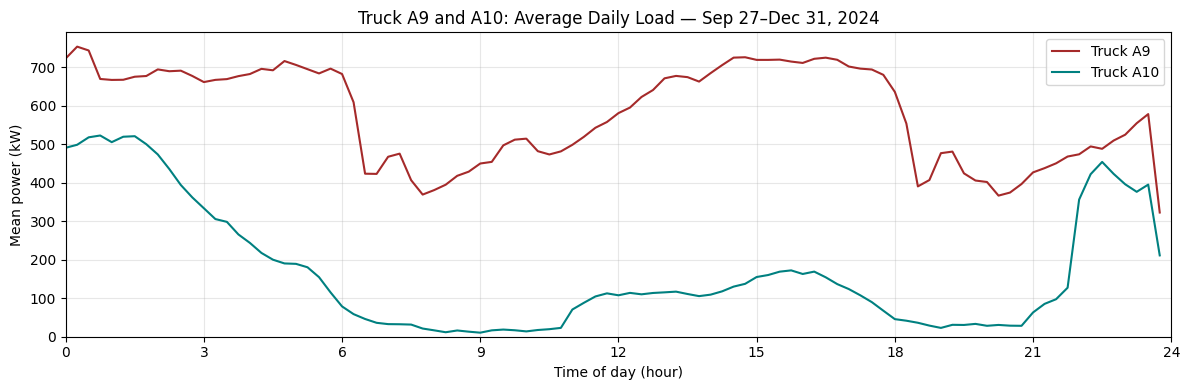

In [63]:
# Average power by time slot within the matched period
def average_power_curve(data):
    working = data.copy()

    working["slot"] = (
        working["datetime"].dt.hour * 4
        + working["datetime"].dt.minute // 15
    )

    return working.groupby("slot")["power"].mean()


mean_curve_a9_shared = average_power_curve(a9_shared)
mean_curve_a10_shared = average_power_curve(a10_shared)

fig_trucks, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    mean_curve_a9_shared.index / 4,
    mean_curve_a9_shared.values,
    label="Truck A9",
    color="brown"
)

ax.plot(
    mean_curve_a10_shared.index / 4,
    mean_curve_a10_shared.values,
    label="Truck A10",
    color="teal"
)

ax.set_title("Truck A9 and A10: Average Daily Load — Sep 27–Dec 31, 2024")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Mean power (kW)")
ax.set_xticks(range(0, 25, 3))
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [64]:
from pathlib import Path
import zipfile

folder = Path("/content/truck_results")
folder.mkdir(exist_ok=True)

# Daily metrics retain each station's available 2024 period
daily_metrics_a9.to_csv(
    folder / "A9_daily_metrics_2024.csv",
    index_label="date"
)

daily_metrics_a10.to_csv(
    folder / "A10_daily_metrics_2024.csv",
    index_label="date"
)

# These curves use only the shared September 27–December 31 period
pd.DataFrame({
    "A9_mean_power_kW": mean_curve_a9_shared,
    "A10_mean_power_kW": mean_curve_a10_shared
}).to_csv(
    folder / "A9_A10_shared_period_curves.csv",
    index_label="slot"
)

pd.DataFrame({
    "station": ["A9", "A10"],
    "period_start": ["2024-09-27", "2024-09-27"],
    "period_end": ["2024-12-31", "2024-12-31"],
    "night_energy_share": [
        night_share_a9_shared,
        night_share_a10_shared
    ]
}).to_csv(folder / "night_energy_shares.csv", index=False)

fig_trucks.savefig(
    folder / "A9_A10_shared_period_curves.png",
    dpi=300,
    bbox_inches="tight"
)

truck_zip = Path("/content/truck_results.zip")

with zipfile.ZipFile(truck_zip, "w", zipfile.ZIP_DEFLATED) as archive:
    for file in folder.iterdir():
        if file.is_file():
            archive.write(file, arcname=file.name)

In [65]:
import pandas as pd

station_ids = ["A1", "A2", "A3", "A4", "A5", "A6", "A9", "A10"]

power_stations = {}

with pd.ExcelFile(workbook_path) as workbook:
    for station in station_ids:
        data = pd.read_excel(workbook, sheet_name=station)

        # Retain calendar 2024
        data = data.loc[
            (data["datetime"] >= "2024-01-01")
            & (data["datetime"] < "2025-01-01")
        ].copy()

        # Store power with datetime as the matching key
        power_stations[station] = (
            data.set_index("datetime")["power"]
            .rename(station)
        )

# Place stations side by side at shared timestamps
aligned_power = pd.concat(
    power_stations.values(),
    axis=1,
    join="inner"
).sort_index()

display(aligned_power.head())

print("Table dimensions:", aligned_power.shape)
print("First timestamp:", aligned_power.index.min())
print("Last timestamp:", aligned_power.index.max())
print("Missing values:", aligned_power.isna().sum().sum())

,A1,A2,A3,A4,A5,A6,A9,A10
datetime,,,,,,,,
2024-09-27 00:00:00,286.9,2052.6,2992.4,4153.9,5.9,44.8,749.5,0.0
2024-09-27 00:15:00,329.6,1951.7,3027.2,6002.1,5.9,44.8,892.9,0.0
2024-09-27 00:30:00,227.9,1841.8,3049.8,6609.9,5.9,42.0,605.6,0.0
2024-09-27 00:45:00,119.8,1601.5,2933.9,6870.2,5.9,38.1,410.1,0.0
2024-09-27 01:00:00,164.1,1466.7,2691.8,7198.4,5.9,38.1,366.8,0.0


Table dimensions: (9216, 8)
First timestamp: 2024-09-27 00:00:00
Last timestamp: 2024-12-31 23:45:00
Missing values: 0


In [66]:
# Add the eight stations' power at each timestamp
combined_load = aligned_power.sum(axis=1, min_count=8)

# Highest combined load in the shared period
combined_peak = combined_load.max()
combined_peak_time = combined_load.idxmax()

# Each station's maximum within that SAME period
individual_peaks = aligned_power.max(axis=0)
sum_of_individual_peaks = individual_peaks.sum()

# Calculate simultaneity
simultaneity = (
    combined_peak / sum_of_individual_peaks
    if sum_of_individual_peaks > 0
    else float("nan")
)

print("Individual station peaks (kW):")
print(individual_peaks)

print(f"\nSum of individual peaks: {sum_of_individual_peaks:.2f} kW")
print(f"Combined peak: {combined_peak:.2f} kW")
print("Combined peak timestamp:", combined_peak_time)
print(f"Simultaneity coefficient: {simultaneity:.4f}")

Individual station peaks (kW):
A1     1688.9
A2     2492.4
A3     3326.8
A4     8211.9
A5       59.9
A6       91.7
A9     1094.7
A10    1310.7
dtype: float64

Sum of individual peaks: 18277.00 kW
Combined peak: 15734.60 kW
Combined peak timestamp: 2024-12-11 23:15:00
Simultaneity coefficient: 0.8609


In [67]:
import pandas as pd
peak_contributions = pd.DataFrame({
    "power_at_combined_peak_kW":
        aligned_power.loc[combined_peak_time],

    "individual_peak_kW":
        individual_peaks
})

peak_contributions["share_of_combined_peak_pct"] = (
    peak_contributions["power_at_combined_peak_kW"]
    / combined_peak * 100
)

display(peak_contributions.round(2))

print(
    "Contribution total:",
    peak_contributions["power_at_combined_peak_kW"].sum(),
    "kW"
)

,power_at_combined_peak_kW,individual_peak_kW,share_of_combined_peak_pct
A1,1053.1,1688.9,6.69
A2,2321.6,2492.4,14.75
A3,2663.2,3326.8,16.93
A4,7865.3,8211.9,49.99
A5,42.1,59.9,0.27
A6,80.4,91.7,0.51
A9,727.5,1094.7,4.62
A10,981.4,1310.7,6.24


Contribution total: 15734.6 kW


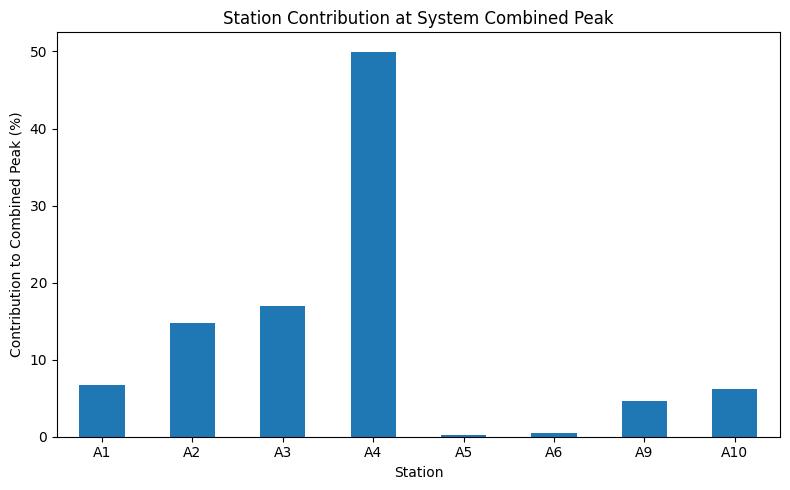

Saved: /content/MP_EVData_Project/report/figures_used/06_simultaneity_contribution.png


In [68]:
import matplotlib.pyplot as plt
from pathlib import Path

save_folder = Path("/content/MP_EVData_Project/report/figures_used")
save_folder.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))

peak_contributions["share_of_combined_peak_pct"].plot(
    kind="bar"
)

plt.ylabel("Contribution to Combined Peak (%)")
plt.xlabel("Station")
plt.title("Station Contribution at System Combined Peak")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    save_folder / "06_simultaneity_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:",
      save_folder / "06_simultaneity_contribution.png")

In [69]:
from pathlib import Path
import zipfile

folder = Path("/content/simultaneity_results")
folder.mkdir(exist_ok=True)

# Save aligned station loads
aligned_power.to_csv(
    folder / "aligned_power_shared_period.csv",
    index_label="datetime"
)

# Save station contributions at the combined peak
peak_contributions.to_csv(
    folder / "combined_peak_contributions.csv",
    index_label="station"
)

# Save the calculation and its scope
pd.DataFrame([{
    "period_start": aligned_power.index.min(),
    "period_end": aligned_power.index.max(),
    "number_of_stations": aligned_power.shape[1],
    "interval_minutes": 15,
    "sum_individual_peaks_kW": sum_of_individual_peaks,
    "combined_peak_kW": combined_peak,
    "combined_peak_time": combined_peak_time,
    "simultaneity": simultaneity
}]).to_csv(folder / "simultaneity_summary.csv", index=False)

# Package and download
simultaneity_zip = Path("/content/simultaneity_results.zip")

with zipfile.ZipFile(
    simultaneity_zip, "w", zipfile.ZIP_DEFLATED
) as archive:
    for file in folder.iterdir():
        if file.is_file():
            archive.write(file, arcname=file.name)


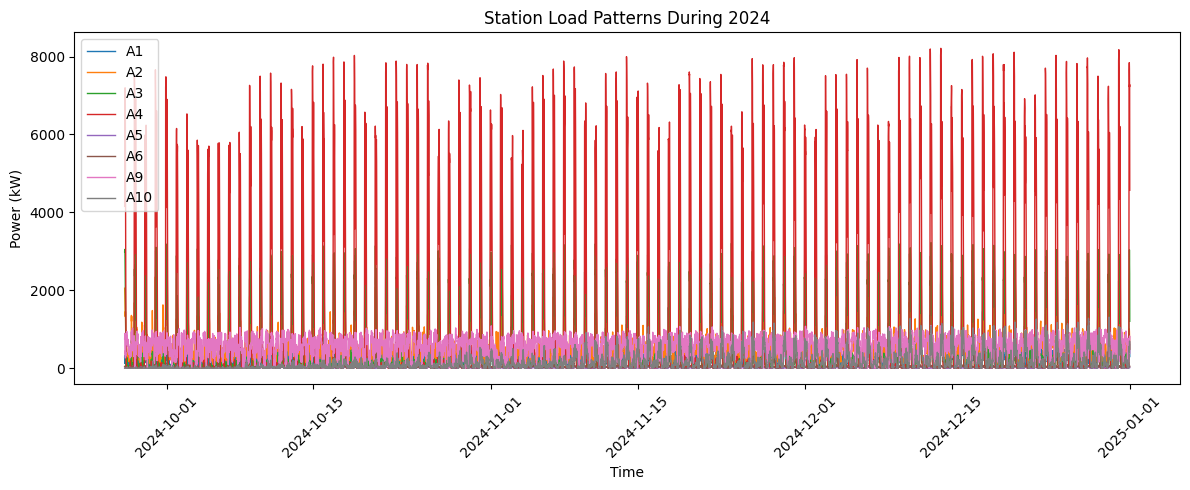

Saved: /content/MP_EVData_Project/report/figures_used/01_station_load_patterns.png


In [70]:
import matplotlib.pyplot as plt
from pathlib import Path

# Create folder
save_folder = Path("/content/MP_EVData_Project/report/figures_used")
save_folder.mkdir(parents=True, exist_ok=True)

# Plot station load patterns
plt.figure(figsize=(12,5))

for station in aligned_power.columns:
    plt.plot(
        aligned_power.index,
        aligned_power[station],
        label=station,
        linewidth=1
    )

plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.title("Station Load Patterns During 2024")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Save figure
plt.savefig(
    save_folder / "01_station_load_patterns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:",
      save_folder / "01_station_load_patterns.png")

In [71]:
# Build one daily-curve table for each power station
daily_curve_tables = []

for station, power_series in power_stations.items():
    data = power_series.rename("power").reset_index()

    data["date"] = data["datetime"].dt.date
    data["slot"] = (
        data["datetime"].dt.hour * 4
        + data["datetime"].dt.minute // 15
    )

    # Rows become days; columns become time slots
    curves = data.pivot(
        index="date",
        columns="slot",
        values="power"
    ).reindex(columns=range(96))

    # Keep only days with all 96 measurements
    curves = curves.dropna()

    # Identify which station each day belongs to
    curves["station"] = station
    curves = curves.set_index("station", append=True)
    curves = curves.reorder_levels(["station", "date"])

    daily_curve_tables.append(curves)

daily_curves_power = pd.concat(daily_curve_tables).sort_index()

display(daily_curves_power.head())

print("Table dimensions:", daily_curves_power.shape)
print("\nComplete days per station:")
print(daily_curves_power.groupby(level="station").size())

slot                   0      1      2      3      4      5      6      7   \
station date                                                                 
A1      2024-01-01  184.4  115.4  275.2  238.7  313.8  320.6  359.3  373.1   
        2024-01-02  692.9  595.9  757.2  695.0  631.7  795.2  733.2  507.5   
        2024-01-03  907.0  874.2  693.3  644.0  610.9  611.9  627.0  475.0   
        2024-01-04  836.6  741.4  805.7  762.6  564.0  499.5  550.5  399.4   
        2024-01-05  940.8  955.0  868.1  768.3  613.3  477.9  506.8  513.9   

slot                   8      9   ...     86     87     88      89      90  \
station date                      ...                                        
A1      2024-01-01  331.7  299.4  ...  329.1  412.5  539.6   740.4   641.0   
        2024-01-02  456.7  458.0  ...  490.4  584.2  933.6   830.0   924.8   
        2024-01-03  533.8  433.2  ...  392.8  547.1  926.4  1152.1  1193.6   
        2024-01-04  237.9  194.5  ...  294.9  353.0  701.8   987.4  1090.5   
        2024-01-05  375.8  411.5  ...  485.7  401.8  838.1  1129.9   989.1   

slot                    91      92     93      94     95  
station date                                              
A1      2024-01-01   888.4   725.0  590.7   467.8  258.3  
        2024-01-02   881.0   625.5  787.8  1096.3  621.9  
        2024-01-03  1208.0   825.5  756.1   792.5  436.8  
        2024-01-04  1045.7  1006.6  900.9   807.0  418.3  
        2024-01-05   582.8   787.7  836.1   970.0  591.8  

[5 rows x 96 columns]

Table dimensions: (2658, 96)

Complete days per station:
station
A1     366
A10     96
A2     366
A3     366
A4     366
A5     366
A6     366
A9     366
dtype: int64


In [72]:
# Check for days with no recorded charging
daily_totals = daily_curves_power.sum(axis=1)
zero_load_days = daily_totals.eq(0)

print("Zero-load days per station:")
print(zero_load_days.groupby(level="station").sum())

# Keep zero-load days in the original table,
# but exclude them from shape clustering
positive_curves = daily_curves_power.loc[~zero_load_days].copy()

# Normalize each day's curve so its 96 values sum to 1
normalized_daily_curves = positive_curves.div(
    daily_totals.loc[~zero_load_days],
    axis=0
)

print("\nNormalized table dimensions:",
      normalized_daily_curves.shape)

print("Smallest row sum:",
      normalized_daily_curves.sum(axis=1).min())

print("Largest row sum:",
      normalized_daily_curves.sum(axis=1).max())

display(normalized_daily_curves.head())

Zero-load days per station:
station
A1     0
A10    0
A2     0
A3     0
A4     0
A5     0
A6     0
A9     0
dtype: int64

Normalized table dimensions: (2658, 96)
Smallest row sum: 0.9999999999999974
Largest row sum: 1.0000000000000022


slot                      0         1         2         3         4   \
station date                                                           
A1      2024-01-01  0.005568  0.003484  0.008309  0.007207  0.009475   
        2024-01-02  0.021557  0.018539  0.023557  0.021622  0.019653   
        2024-01-03  0.024372  0.023490  0.018630  0.017305  0.016415   
        2024-01-04  0.025784  0.022850  0.024831  0.023503  0.017382   
        2024-01-05  0.024810  0.025184  0.022892  0.020261  0.016173   

slot                      5         6         7         8         9   ...  \
station date                                                          ...   
A1      2024-01-01  0.009680  0.010849  0.011265  0.010015  0.009040  ...   
        2024-01-02  0.024739  0.022810  0.015789  0.014208  0.014249  ...   
        2024-01-03  0.016442  0.016848  0.012764  0.014344  0.011640  ...   
        2024-01-04  0.015394  0.016966  0.012309  0.007332  0.005994  ...   
        2024-01-05  0.012603  0.013365  0.013552  0.009910  0.010852  ...   

slot                      86        87        88        89        90  \
station date                                                           
A1      2024-01-01  0.009937  0.012455  0.016293  0.022355  0.019354   
        2024-01-02  0.015257  0.018175  0.029045  0.025822  0.028771   
        2024-01-03  0.010555  0.014701  0.024893  0.030958  0.032073   
        2024-01-04  0.009089  0.010879  0.021629  0.030431  0.033609   
        2024-01-05  0.012808  0.010596  0.022101  0.029796  0.026083   

slot                      91        92        93        94        95  
station date                                                          
A1      2024-01-01  0.026824  0.021890  0.017835  0.014125  0.007799  
        2024-01-02  0.027409  0.019460  0.024509  0.034107  0.019348  
        2024-01-03  0.032460  0.022182  0.020317  0.021295  0.011737  
        2024-01-04  0.032228  0.031023  0.027765  0.024871  0.012892  
        2024-01-05  0.015369  0.020772  0.022049  0.025580  0.015606  

[5 rows x 96 columns]

k=2: silhouette=0.4490
k=3: silhouette=0.2548
k=4: silhouette=0.2820
k=5: silhouette=0.2641
k=6: silhouette=0.2722
k=7: silhouette=0.2476
k=8: silhouette=0.2326


,k,inertia,silhouette
0,2,11.810927,0.448966
1,3,10.455219,0.254805
2,4,9.375517,0.282046
3,5,8.620943,0.264141
4,6,8.156860,0.272164
5,7,7.834927,0.247625
6,8,7.536073,0.232618


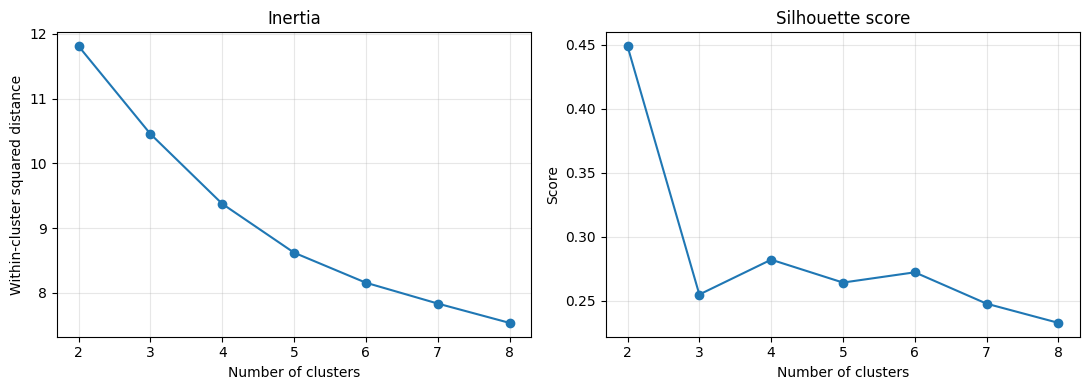

In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = normalized_daily_curves.to_numpy()

clustering_results = []
kmeans_models = {}

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)
    kmeans_models[k] = model

    silhouette = silhouette_score(
        X,
        labels,
        sample_size=1200,
        random_state=42
    )

    clustering_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette
    })

    print(f"k={k}: silhouette={silhouette:.4f}")

clustering_scores = pd.DataFrame(clustering_results)
display(clustering_scores)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    clustering_scores["k"],
    clustering_scores["inertia"],
    marker="o"
)
axes[0].set_title("Inertia")
axes[0].set_ylabel("Within-cluster squared distance")

axes[1].plot(
    clustering_scores["k"],
    clustering_scores["silhouette"],
    marker="o"
)
axes[1].set_title("Silhouette score")
axes[1].set_ylabel("Score")

for ax in axes:
    ax.set_xlabel("Number of clusters")
    ax.set_xticks(range(2, 9))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

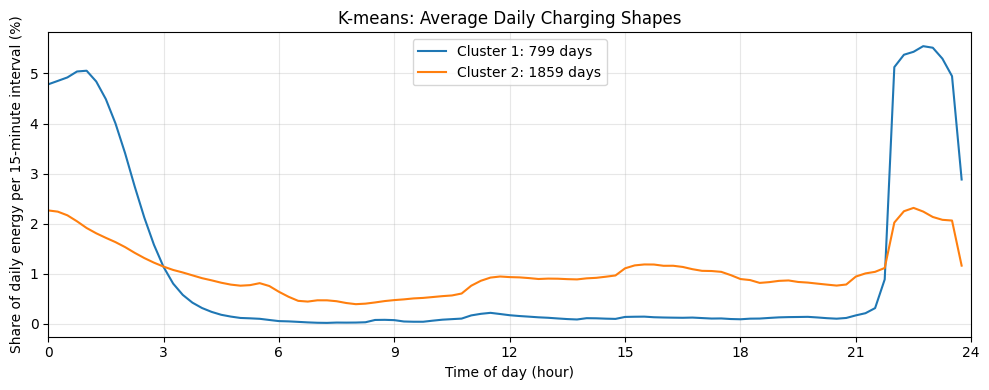

Number of days by station and cluster:


cluster,1,2
station,,
A1,1,365
A10,0,96
A2,0,366
A3,326,40
A4,363,3
A5,108,258
A6,0,366
A9,1,365


Percentage of each station's days:


cluster,1,2
station,,
A1,0.3,99.7
A10,0.0,100.0
A2,0.0,100.0
A3,89.1,10.9
A4,99.2,0.8
A5,29.5,70.5
A6,0.0,100.0
A9,0.3,99.7


In [74]:
chosen_k = 2
chosen_model = kmeans_models[chosen_k]

# Use labels from the model we already fitted
cluster_assignments = pd.Series(
    chosen_model.labels_ + 1,
    index=normalized_daily_curves.index,
    name="cluster"
)

# Cluster centres are average normalized daily curves
hours = normalized_daily_curves.columns.to_numpy() / 4

fig_clusters, ax = plt.subplots(figsize=(10, 4))

for cluster in range(chosen_k):
    number_of_days = (cluster_assignments == cluster + 1).sum()

    ax.plot(
        hours,
        chosen_model.cluster_centers_[cluster] * 100,
        label=f"Cluster {cluster + 1}: {number_of_days} days"
    )

ax.set_title("K-means: Average Daily Charging Shapes")
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel("Share of daily energy per 15-minute interval (%)")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Count station-days in each cluster
assignment_table = cluster_assignments.reset_index()

station_cluster_counts = pd.crosstab(
    assignment_table["station"],
    assignment_table["cluster"]
)

# Percentages allow comparison despite A10's shorter coverage
station_cluster_percentages = (
    station_cluster_counts
    .div(station_cluster_counts.sum(axis=1), axis=0)
    .mul(100)
)

print("Number of days by station and cluster:")
display(station_cluster_counts)

print("Percentage of each station's days:")
display(station_cluster_percentages.round(1))

In [75]:
# Slots 0–23: midnight–05:45
# Slots 88–95: 22:00–23:45
night_slots = list(range(24)) + list(range(88, 96))

cluster_day_features = pd.DataFrame({
    "cluster": cluster_assignments,
    "night_energy_share_pct": (
        normalized_daily_curves[night_slots].sum(axis=1) * 100
    )
})

cluster_summary = cluster_day_features.groupby("cluster").agg(
    station_days=("night_energy_share_pct", "size"),
    mean_night_share_pct=("night_energy_share_pct", "mean"),
    median_night_share_pct=("night_energy_share_pct", "median"),
    lowest_night_share_pct=("night_energy_share_pct", "min"),
    highest_night_share_pct=("night_energy_share_pct", "max")
)

display(cluster_summary.round(2))

,station_days,mean_night_share_pct,median_night_share_pct,lowest_night_share_pct,highest_night_share_pct
cluster,,,,,
1,799,92.18,93.57,58.88,100.0
2,1859,48.27,46.32,5.94,100.0


In [76]:
from pathlib import Path
import zipfile

results_folder = Path("/content/kmeans_results")
results_folder.mkdir(exist_ok=True)

normalized_daily_curves.to_csv(
    results_folder / "normalized_daily_curves.csv"
)

cluster_day_features.to_csv(
    results_folder / "daily_cluster_assignments.csv"
)

clustering_scores.to_csv(
    results_folder / "cluster_selection_scores.csv",
    index=False
)

cluster_summary.to_csv(
    results_folder / "cluster_summary.csv"
)

station_cluster_counts.to_csv(
    results_folder / "station_cluster_counts.csv"
)

station_cluster_percentages.to_csv(
    results_folder / "station_cluster_percentages.csv"
)

pd.DataFrame(
    chosen_model.cluster_centers_,
    index=pd.Index(range(1, chosen_k + 1), name="cluster"),
    columns=normalized_daily_curves.columns
).to_csv(results_folder / "cluster_centres.csv")

fig_clusters.savefig(
    results_folder / "cluster_shapes.png",
    dpi=300,
    bbox_inches="tight"
)

(results_folder / "README.txt").write_text(
    "Exploratory K-means on MP-EVData daily electrical load curves.\n"
    "Stations: A1-A6, A9, A10; A7/A8 counts excluded.\n"
    "Coverage: available complete days in 2024; A10 has 96 days.\n"
    "Input: 2658 station-days, each with 96 quarter-hour values.\n"
    "Normalization: each curve divided by its daily power sum.\n"
    "KMeans: random_state=42, n_init=10; tested k=2 through 8.\n"
    "Silhouette: sample_size=1200, random_state=42.\n"
    "Selected candidate: k=2, sampled silhouette approximately 0.449.\n"
    "Night window: 22:00-06:00; descriptive, not a tariff definition.\n"
    "Cluster summaries weight each station-day equally.\n"
    "Cluster numbers are arbitrary identifiers.\n",
    encoding="utf-8"
)

zip_path = Path("/content/kmeans_results.zip")

with zipfile.ZipFile(
    zip_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(results_folder.iterdir()):
        archive.write(path, arcname=path.name)


In [77]:
print("ZIP exists:", zip_path.exists())

if zip_path.exists():
    print("ZIP size:", zip_path.stat().st_size, "bytes")

ZIP exists: True
ZIP size: 1818749 bytes


In [78]:
station_type_map = {
    "A1": "taxi",
    "A2": "taxi",
    "A3": "bus",
    "A4": "bus",
    "A5": "residential",
    "A6": "residential",
    "A9": "truck",
    "A10": "truck"
}

# Inputs: 96 normalized quarter-hour values per day
X_rf = normalized_daily_curves.copy()

# Station identifiers are used for splitting, not as predictors
station_groups = pd.Series(
    X_rf.index.get_level_values("station"),
    index=X_rf.index,
    name="station"
)

# Target: the known station type
y_rf = station_groups.map(station_type_map).rename("station_type")

print("Input dimensions:", X_rf.shape)
print("Missing type labels:", y_rf.isna().sum())

print("\nDaily samples per type:")
display(y_rf.value_counts())

print("\nStations and their types:")
display(
    pd.DataFrame({
        "station": station_groups,
        "station_type": y_rf
    }).drop_duplicates().reset_index(drop=True)
)

Input dimensions: (2658, 96)
Missing type labels: 0

Daily samples per type:


,count
station_type,
taxi,732
bus,732
residential,732
truck,462



Stations and their types:


,station,station_type
0,A1,taxi
1,A10,truck
2,A2,taxi
3,A3,bus
4,A4,bus
5,A5,residential
6,A6,residential
7,A9,truck


In [79]:
fold_definitions = {
    1: {
        "train": ["A1", "A3", "A5", "A9"],
        "test": ["A2", "A4", "A6", "A10"]
    },
    2: {
        "train": ["A2", "A4", "A6", "A10"],
        "test": ["A1", "A3", "A5", "A9"]
    }
}

rf_splits = {}

for fold, stations in fold_definitions.items():
    train_mask = station_groups.isin(stations["train"])
    test_mask = station_groups.isin(stations["test"])

    X_train = X_rf.loc[train_mask]
    X_test = X_rf.loc[test_mask]
    y_train = y_rf.loc[train_mask]
    y_test = y_rf.loc[test_mask]

    # Verify that stations do not overlap
    train_stations = set(station_groups.loc[train_mask])
    test_stations = set(station_groups.loc[test_mask])
    assert train_stations.isdisjoint(test_stations)

    rf_splits[fold] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print(f"\nFold {fold}")
    print("Training stations:", sorted(train_stations))
    print("Test stations:", sorted(test_stations))
    print("Training dimensions:", X_train.shape)
    print("Test dimensions:", X_test.shape)

    display(pd.DataFrame({
        "training_days": y_train.value_counts(),
        "test_days": y_test.value_counts()
    }).fillna(0).astype(int))


Fold 1
Training stations: ['A1', 'A3', 'A5', 'A9']
Test stations: ['A10', 'A2', 'A4', 'A6']
Training dimensions: (1464, 96)
Test dimensions: (1194, 96)


,training_days,test_days
station_type,,
taxi,366,366
bus,366,366
residential,366,366
truck,366,96



Fold 2
Training stations: ['A10', 'A2', 'A4', 'A6']
Test stations: ['A1', 'A3', 'A5', 'A9']
Training dimensions: (1194, 96)
Test dimensions: (1464, 96)


,training_days,test_days
station_type,,
taxi,366,366
bus,366,366
residential,366,366
truck,96,366


In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

rf_models = {}
rf_prediction_tables = []
rf_scores = []

for fold, split in rf_splits.items():
    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(split["X_train"], split["y_train"])
    predictions = model.predict(split["X_test"])

    rf_models[fold] = model

    rf_scores.append({
        "fold": fold,
        "accuracy": accuracy_score(
            split["y_test"], predictions
        ),
        "balanced_accuracy": balanced_accuracy_score(
            split["y_test"], predictions
        ),
        "macro_f1": f1_score(
            split["y_test"], predictions,
            average="macro",
            zero_division=0
        )
    })

    prediction_table = pd.DataFrame({
        "actual_type": split["y_test"],
        "predicted_type": predictions
    })
    prediction_table["fold"] = fold
    rf_prediction_tables.append(prediction_table)

    print(f"\nFold {fold}:")
    print(classification_report(
        split["y_test"],
        predictions,
        digits=3,
        zero_division=0
    ))

rf_scores = pd.DataFrame(rf_scores)

# Each day's prediction comes from a model
# trained without that station
rf_predictions = pd.concat(
    rf_prediction_tables
).sort_index()

print("\nScores by fold:")
display(rf_scores.round(3))


Fold 1:
              precision    recall  f1-score   support

         bus      1.000     0.989     0.995       366
 residential      0.763     0.730     0.746       366
        taxi      0.780     1.000     0.877       366
       truck      0.154     0.021     0.037        96

    accuracy                          0.835      1194
   macro avg      0.674     0.685     0.663      1194
weighted avg      0.792     0.835     0.805      1194


Fold 2:
              precision    recall  f1-score   support

         bus      0.801     0.691     0.742       366
 residential      0.353     0.372     0.362       366
        taxi      0.672     0.773     0.719       366
       truck      0.035     0.033     0.034       366

    accuracy                          0.467      1464
   macro avg      0.465     0.467     0.464      1464
weighted avg      0.465     0.467     0.464      1464


Scores by fold:


,fold,accuracy,balanced_accuracy,macro_f1
0,1,0.835,0.685,0.663
1,2,0.467,0.467,0.464


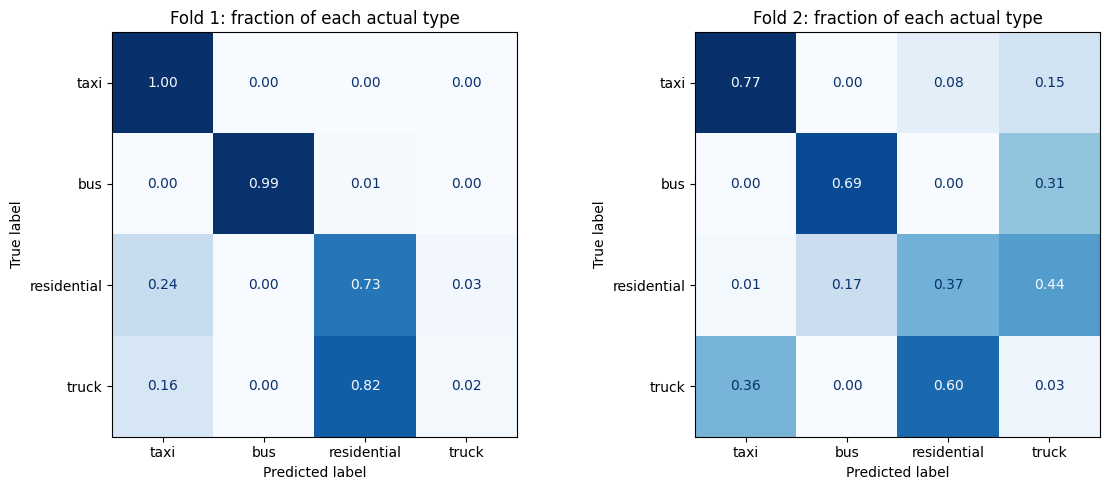

,actual_type,tested_days,accuracy
station,,,
A1,taxi,366,0.773
A10,truck,96,0.021
A2,taxi,366,1.000
A3,bus,366,0.691
A4,bus,366,0.989
A5,residential,366,0.372
A6,residential,366,0.730
A9,truck,366,0.033


In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

type_order = ["taxi", "bus", "residential", "truck"]

fig_rf_confusion, axes = plt.subplots(
    1, 2, figsize=(12, 5)
)

for ax, fold in zip(axes, [1, 2]):
    fold_predictions = rf_predictions.loc[
        rf_predictions["fold"] == fold
    ]

    matrix = confusion_matrix(
        fold_predictions["actual_type"],
        fold_predictions["predicted_type"],
        labels=type_order,
        normalize="true"
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=type_order
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format=".2f",
        colorbar=False
    )

    ax.set_title(f"Fold {fold}: fraction of each actual type")

plt.tight_layout()
plt.show()

# Accuracy for each held-out station
station_prediction_summary = (
    rf_predictions
    .assign(
        correct=lambda table:
            table["actual_type"].eq(table["predicted_type"])
    )
    .groupby(level="station")
    .agg(
        actual_type=("actual_type", "first"),
        tested_days=("correct", "size"),
        accuracy=("correct", "mean")
    )
)

display(station_prediction_summary.round(3))

In [82]:
import importlib.util

if importlib.util.find_spec("shap") is None:
    print("SHAP is not installed.")
else:
    import shap
    import sklearn

    print("SHAP version:", shap.__version__)
    print("scikit-learn version:", sklearn.__version__)

SHAP version: 0.52.0
scikit-learn version: 1.6.1


In [83]:
import numpy as np

shap_samples = {}
shap_explanations = {}

for fold, split in rf_splits.items():
    # Select 20 days from each held-out station
    sample = (
        split["X_test"]
        .groupby(level="station", group_keys=False)
        .sample(n=20, random_state=42)
        .sort_index()
    )

    # Explain the fitted forest using its training-tree paths
    explainer = shap.TreeExplainer(
        rf_models[fold],
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )

    explanation = explainer(sample)

    shap_samples[fold] = sample
    shap_explanations[fold] = explanation

    # Verify that SHAP reconstructs predicted probabilities
    reconstructed = (
        explanation.base_values
        + explanation.values.sum(axis=1)
    )

    probabilities = rf_models[fold].predict_proba(sample)

    largest_difference = np.abs(
        reconstructed - probabilities
    ).max()

    print(f"\nFold {fold}")
    print("Sample dimensions:", sample.shape)
    print("SHAP values dimensions:", explanation.values.shape)
    print("Class order:", rf_models[fold].classes_)
    print("Largest reconstruction difference:",
          largest_difference)


Fold 1
Sample dimensions: (80, 96)
SHAP values dimensions: (80, 96, 4)
Class order: ['bus' 'residential' 'taxi' 'truck']
Largest reconstruction difference: 4.440892098500626e-16

Fold 2
Sample dimensions: (80, 96)
SHAP values dimensions: (80, 96, 4)
Class order: ['bus' 'residential' 'taxi' 'truck']
Largest reconstruction difference: 1.1102230246251565e-15



Fold 1:


,slot,mean_absolute_shap,time
90,90,0.0235,22:30
6,6,0.0192,01:30
89,89,0.0174,22:15
4,4,0.0168,01:00
66,66,0.0165,16:30
5,5,0.0153,01:15
91,91,0.0146,22:45
65,65,0.0145,16:15
29,29,0.0144,07:15
64,64,0.0124,16:00



Fold 2:


,slot,mean_absolute_shap,time
4,4,0.0206,01:00
76,76,0.0188,19:00
89,89,0.0174,22:15
90,90,0.0152,22:30
80,80,0.0143,20:00
92,92,0.0140,23:00
78,78,0.0138,19:30
77,77,0.0129,19:15
75,75,0.0128,18:45
35,35,0.0123,08:45


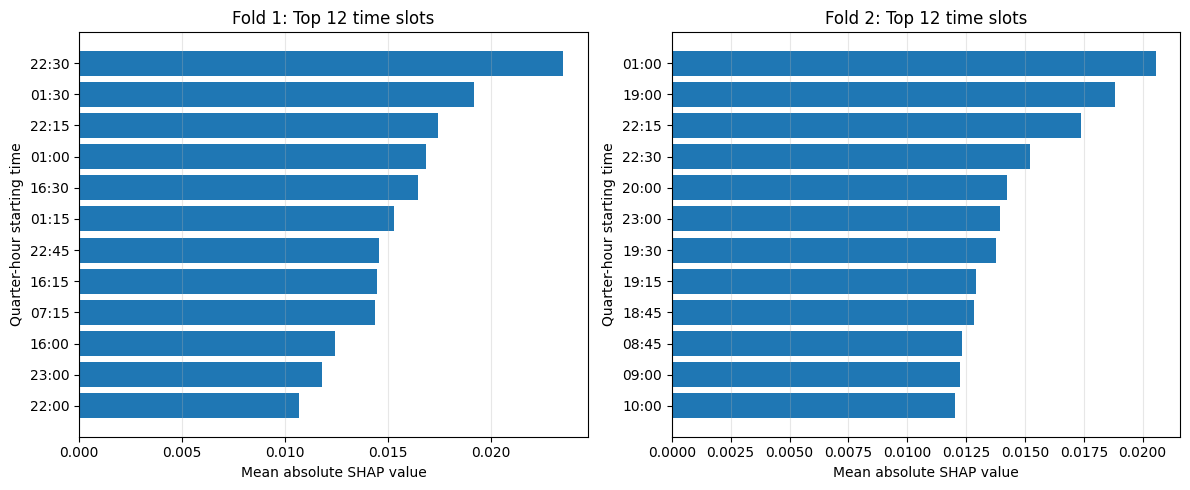

In [84]:
shap_importance_tables = {}

fig_shap_importance, axes = plt.subplots(
    1, 2, figsize=(12, 5)
)

for ax, fold in zip(axes, [1, 2]):
    values = shap_explanations[fold].values

    # Average contribution magnitude across days and classes
    importance = np.abs(values).mean(axis=(0, 2))

    table = pd.DataFrame({
        "slot": shap_samples[fold].columns,
        "mean_absolute_shap": importance
    })

    table["time"] = table["slot"].map(
        lambda slot: f"{slot // 4:02d}:{(slot % 4) * 15:02d}"
    )

    table = table.sort_values(
        "mean_absolute_shap", ascending=False
    )

    shap_importance_tables[fold] = table

    top_slots = table.head(12).sort_values(
        "mean_absolute_shap"
    )

    ax.barh(
        top_slots["time"],
        top_slots["mean_absolute_shap"]
    )
    ax.set_title(f"Fold {fold}: Top 12 time slots")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("Quarter-hour starting time")
    ax.grid(axis="x", alpha=0.3)

    print(f"\nFold {fold}:")
    display(table.head(12).round(4))

plt.tight_layout()
plt.show()

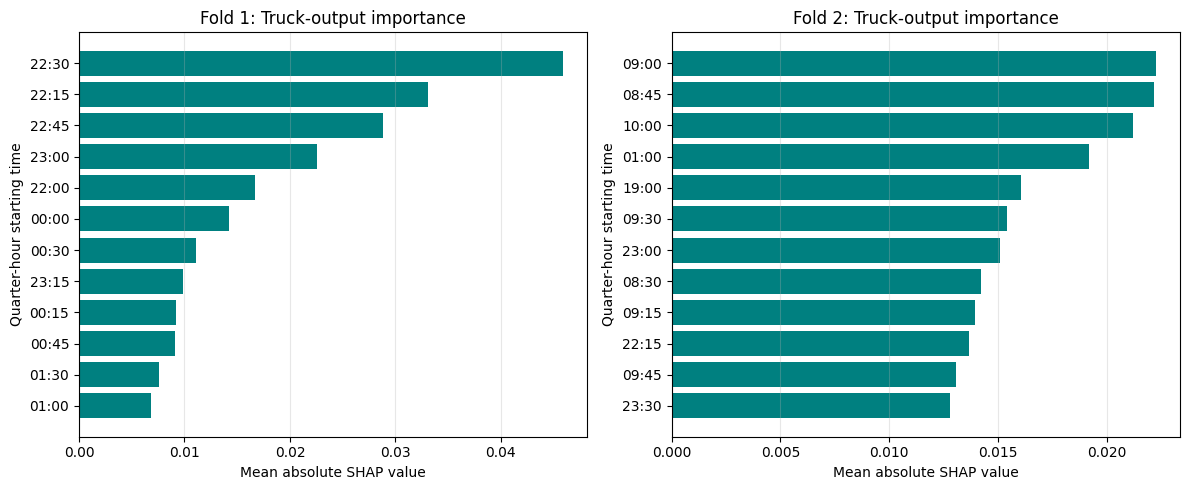

In [85]:
fig_shap_truck, axes = plt.subplots(
    1, 2, figsize=(12, 5)
)

for ax, fold in zip(axes, [1, 2]):
    # Find the truck output in this model's class order
    truck_index = list(
        rf_models[fold].classes_
    ).index("truck")

    # Contributions to truck probability across all sampled days
    truck_values = (
        shap_explanations[fold].values[:, :, truck_index]
    )

    importance = np.abs(truck_values).mean(axis=0)

    table = pd.DataFrame({
        "slot": shap_samples[fold].columns,
        "mean_absolute_shap": importance
    })

    table["time"] = table["slot"].map(
        lambda slot: f"{slot // 4:02d}:{(slot % 4) * 15:02d}"
    )

    top_slots = (
        table.nlargest(12, "mean_absolute_shap")
        .sort_values("mean_absolute_shap")
    )

    ax.barh(
        top_slots["time"],
        top_slots["mean_absolute_shap"],
        color="teal"
    )
    ax.set_title(f"Fold {fold}: Truck-output importance")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("Quarter-hour starting time")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Fold: 1
Station: A10
Date: 2024-10-01
Actual type: truck
Predicted type: residential


,Predicted probability
bus,0.066
residential,0.636
taxi,0.088
truck,0.211


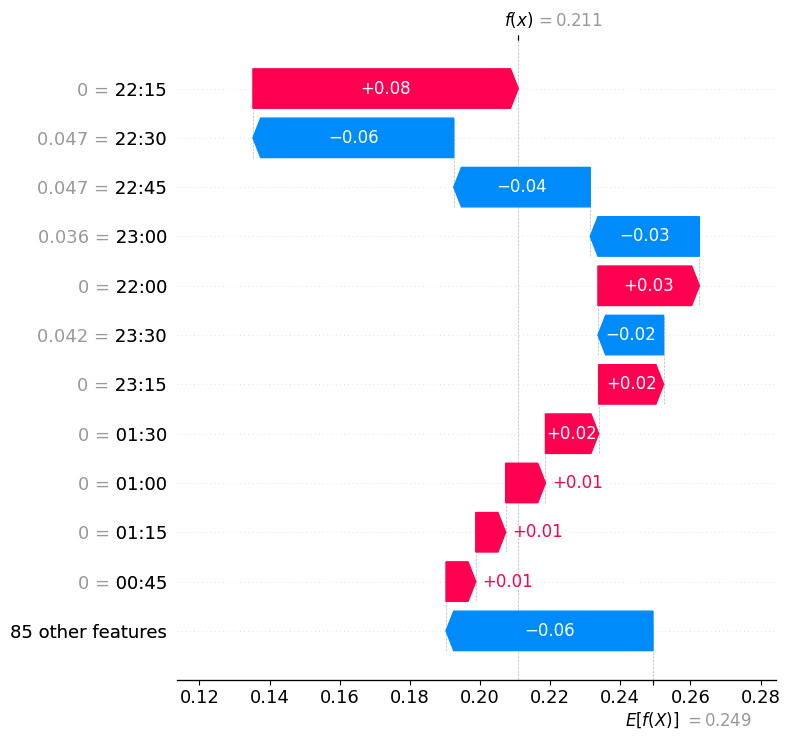

In [86]:
# Find the first truck → residential example in our samples
selected_case = None

for fold in [1, 2]:
    sample = shap_samples[fold]
    actual = y_rf.loc[sample.index]
    predicted = rf_models[fold].predict(sample)

    positions = np.flatnonzero(
        actual.eq("truck").to_numpy()
        & (predicted == "residential")
    )

    if len(positions):
        selected_case = (fold, int(positions[0]))
        break

if selected_case is None:
    print("No truck → residential example in this sample.")
else:
    fold, position = selected_case
    sample = shap_samples[fold]
    model = rf_models[fold]
    explanation = shap_explanations[fold]

    station, date = sample.index[position]

    print("Fold:", fold)
    print("Station:", station)
    print("Date:", date)
    print("Actual type: truck")
    print("Predicted type: residential")

    display(pd.Series(
        model.predict_proba(sample.iloc[[position]])[0],
        index=model.classes_,
        name="Predicted probability"
    ).round(3))

    truck_index = list(model.classes_).index("truck")

    truck_day_explanation = shap.Explanation(
        values=explanation.values[position, :, truck_index],
        base_values=explanation.base_values[position, truck_index],
        data=sample.iloc[position].to_numpy(),
        feature_names=[
            f"{slot // 4:02d}:{(slot % 4) * 15:02d}"
            for slot in sample.columns
        ]
    )

    shap.plots.waterfall(
        truck_day_explanation,
        max_display=12,
        show=False
    )

    fig_shap_truck_day = plt.gcf()
    plt.tight_layout()
    plt.show()

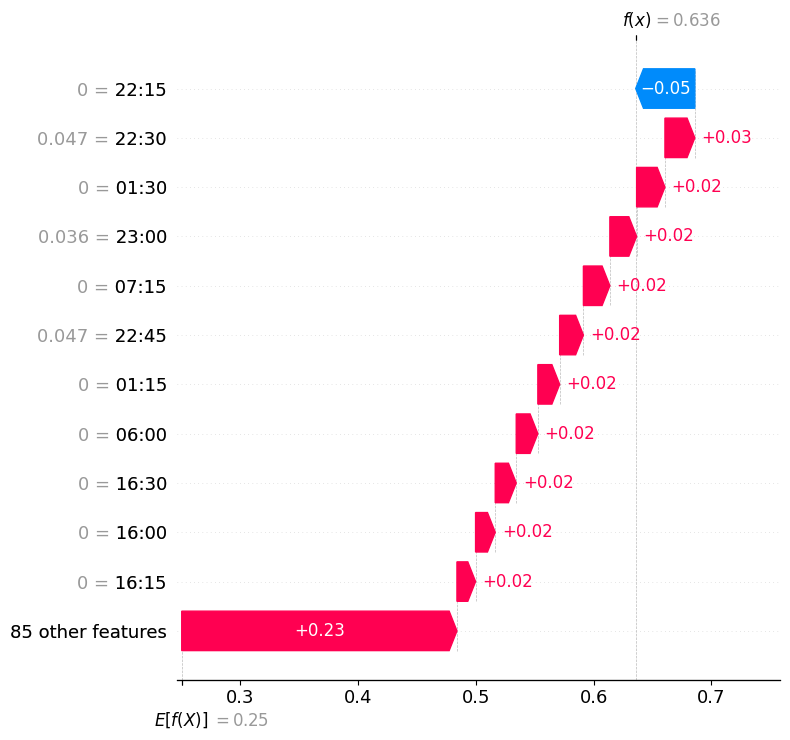

In [87]:
residential_index = list(model.classes_).index("residential")

residential_day_explanation = shap.Explanation(
    values=explanation.values[position, :, residential_index],
    base_values=explanation.base_values[position, residential_index],
    data=sample.iloc[position].to_numpy(),
    feature_names=[
        f"{slot // 4:02d}:{(slot % 4) * 15:02d}"
        for slot in sample.columns
    ]
)

shap.plots.waterfall(
    residential_day_explanation,
    max_display=12,
    show=False
)

fig_shap_residential_day = plt.gcf()
plt.tight_layout()
plt.show()

In [88]:
from pathlib import Path
import zipfile
import joblib

rf_folder = Path("/content/rf_shap_results")
rf_folder.mkdir(exist_ok=True)

# Evaluation results
rf_scores.to_csv(rf_folder / "fold_scores.csv", index=False)
rf_predictions.to_csv(rf_folder / "held_out_predictions.csv")
station_prediction_summary.to_csv(
    rf_folder / "station_accuracy.csv"
)

# Models, SHAP samples and contributions
for fold in [1, 2]:
    joblib.dump(
        rf_models[fold],
        rf_folder / f"random_forest_fold_{fold}.joblib"
    )

    shap_samples[fold].to_csv(
        rf_folder / f"shap_sample_fold_{fold}.csv"
    )

    shap_importance_tables[fold].to_csv(
        rf_folder / f"shap_importance_fold_{fold}.csv",
        index=False
    )

    np.savez_compressed(
        rf_folder / f"shap_values_fold_{fold}.npz",
        values=shap_explanations[fold].values,
        base_values=shap_explanations[fold].base_values,
        classes=rf_models[fold].classes_
    )

# Figures
figures = {
    "confusion_matrices.png": fig_rf_confusion,
    "shap_overall_importance.png": fig_shap_importance,
    "shap_truck_importance.png": fig_shap_truck,
    "shap_truck_day.png": fig_shap_truck_day,
    "shap_residential_day.png": fig_shap_residential_day
}

for filename, figure in figures.items():
    figure.savefig(
        rf_folder / filename,
        dpi=300,
        bbox_inches="tight"
    )

# Document choices needed to reproduce the analysis
(rf_folder / "README.txt").write_text(
    "Exploratory four-type Random Forest classification.\n"
    "Inputs: 96 daily-total-normalized electrical load values.\n"
    "Stations: A1/A2 taxi; A3/A4 bus; A5/A6 residential; A9/A10 truck.\n"
    "Battery-swap count stations A7/A8 excluded from this baseline.\n"
    "Fold 1 train: A1,A3,A5,A9; test: A2,A4,A6,A10.\n"
    "Fold 2 reverses those training and test stations.\n"
    "RF: 300 trees, min_samples_leaf=2, class_weight=balanced,\n"
    "random_state=42; remaining parameters use library defaults.\n"
    "SHAP: 20 test days per station per fold, random_state=42.\n"
    "TreeExplainer: tree_path_dependent, model_output=raw.\n"
    "SHAP reconstruction checked against predicted probabilities.\n"
    "Overall importance averages absolute SHAP across days and classes.\n"
    f"Illustrative case: fold {selected_case[0]}, "
    f"{station}, {date}; actual truck, predicted residential.\n"
    f"scikit-learn version: {sklearn.__version__}\n"
    f"SHAP version: {shap.__version__}\n"
    "Only two stations per type; results are exploratory.\n"
    "SHAP explains fitted predictions, not causal charging behaviour.\n",
    encoding="utf-8"
)

rf_zip = Path("/content/rf_shap_results.zip")

with zipfile.ZipFile(
    rf_zip, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(rf_folder.iterdir()):
        archive.write(path, arcname=path.name)

In [89]:
price_files = list(extract_folder.rglob("price.xlsx"))

print("Price workbooks found:", len(price_files))

if price_files:
    price_path = price_files[0]

    with pd.ExcelFile(price_path) as price_workbook:
        print("Sheets:", price_workbook.sheet_names)

        first_sheet = price_workbook.sheet_names[0]
        price_preview = pd.read_excel(
            price_workbook,
            sheet_name=first_sheet,
            nrows=10
        )

    print("\nPreview of:", first_sheet)
    display(price_preview)
else:
    print("price.xlsx was not found in the extracted dataset.")

Price workbooks found: 1
Sheets: ['站点确定', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']

Preview of: 站点确定


,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
0,Taxi Demonstration Station,A1,80.0,88.2,5000,DC,Time-of-Use Pricing
1,Taxi Demonstration Station,A2,60.0,230.0,4500,DC,Time-of-Use Pricing
2,Bus Depot,A3,120.0,54.8,2500,DC,Time-of-Use Pricing
3,Bus Depot,A4,150.0,99.4,12000,DC,Free
4,Residential Charging Station,A5,7.0,3.3,100,AC,Time-of-Use Pricing
5,Residential Charging Station,A6,7.0,12.7,56,AC,Time-of-Use Pricing
6,NaN,NaN,NaN,NaN,56,NaN,NaN
7,NaN,NaN,NaN,NaN,84,NaN,NaN
8,Battery Swapping Station,A7,2400.0,353.6,2000,Snap-fit Battery Swap,Time-of-Use Pricing
9,Battery Swapping Station,A8,60.0,8.2,1600,Bolt-on Battery Swap,NaN


In [90]:
with pd.ExcelFile(price_path) as price_workbook:
    price_a1 = pd.read_excel(
        price_workbook,
        sheet_name="A1"
    )

print("A1 tariff table dimensions:", price_a1.shape)

print("\nColumn names:")
print(price_a1.columns.tolist())

print("\nFirst 15 rows:")
display(price_a1.head(15))

print("\nData types:")
print(price_a1.dtypes)

print("\nMissing values:")
print(price_a1.isna().sum())

A1 tariff table dimensions: (40, 5)

Column names:
['Month', 'Period', 'Total Price(RMB)', 'Electricity Price(RMB)', 'Service Price(RMB)']

First 15 rows:


,Month,Period,Total Price(RMB),Electricity Price(RMB),Service Price(RMB)
0,1,Sharp(19:00-21:00),1.80,1.3648,0.4352
1,1,"Peak(08:00-11:00,18:00-21:00)",1.35,1.1142,0.2358
2,1,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.15,0.6687,0.4813
3,1,"Off-peak(00:00-06:00,22:00-00:00)",0.95,0.3345,0.6155
4,2,"Peak(08:00-11:00,18:00-21:00)",1.35,1.0321,0.3179
5,2,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.15,0.6803,0.4697
6,2,"Off-peak(00:00-06:00,22:00-00:00)",0.95,0.3872,0.5628
7,3,"Peak(08:00-11:00,18:00-21:00)",1.35,1.0502,0.2998
8,3,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.15,0.6931,0.4569
9,3,"Off-peak(00:00-06:00,22:00-00:00)",0.95,0.3955,0.5545



Data types:
Month                       int64
Period                     object
Total Price(RMB)          float64
Electricity Price(RMB)    float64
Service Price(RMB)        float64
dtype: object

Missing values:
Month                     0
Period                    0
Total Price(RMB)          0
Electricity Price(RMB)    0
Service Price(RMB)        0
dtype: int64


In [91]:
# Short period labels, while retaining the original schedule text
a1_tariffs = price_a1.copy()
a1_tariffs["period_type"] = (
    a1_tariffs["Period"].str.split("(").str[0].str.strip()
)

print("Months present:")
print(sorted(a1_tariffs["Month"].unique()))

print("\nDistinct schedules:")
display(
    a1_tariffs[["period_type", "Period"]].drop_duplicates()
)

print("\nTotal prices by month and period:")
display(a1_tariffs.pivot(
    index="Month",
    columns="period_type",
    values="Total Price(RMB)"
))

# Check total price = electricity price + service price
difference = (
    a1_tariffs["Total Price(RMB)"]
    - a1_tariffs["Electricity Price(RMB)"]
    - a1_tariffs["Service Price(RMB)"]
).abs()

print("\nLargest price-component difference:",
      difference.max())

Months present:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Distinct schedules:


,period_type,Period
0,Sharp,Sharp(19:00-21:00)
1,Peak,"Peak(08:00-11:00,18:00-21:00)"
2,Shoulder,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)"
3,Off-peak,"Off-peak(00:00-06:00,22:00-00:00)"
19,Sharp,Sharp(12:00-14:00)
20,Peak,"Peak(08:00-15:00,18:00-21:00)"
21,Shoulder,"Shoulder(06:00-08:00,15:00-18:00,21:00-22:00)"



Total prices by month and period:


period_type,Off-peak,Peak,Sharp,Shoulder
Month,,,,
1,0.9500,1.3500,1.8,1.1500
2,0.9500,1.3500,NaN,1.1500
3,0.9500,1.3500,NaN,1.1500
4,0.9500,1.3500,NaN,1.1500
5,0.9500,1.3500,NaN,1.1500
6,0.9500,1.3500,NaN,1.1500
7,0.9500,1.3500,1.8,1.1500
8,0.9500,1.4000,1.8,1.1500
9,0.7045,1.2987,NaN,0.9782



Largest price-component difference: 1.942890293094024e-16


In [92]:
a1_tariffs = price_a1.copy()

a1_tariffs["period_type"] = (
    a1_tariffs["Period"]
    .str.split("(")
    .str[0]
    .str.strip()
)

print("Months present:")
print(sorted(a1_tariffs["Month"].unique()))

print("\nDistinct period definitions:")
display(
    a1_tariffs[
        ["period_type", "Period"]
    ].drop_duplicates()
)

print("\nTotal prices by month and period:")
display(
    a1_tariffs.pivot(
        index="Month",
        columns="period_type",
        values="Total Price(RMB)"
    )
)

difference = (
    a1_tariffs["Total Price(RMB)"]
    - a1_tariffs["Electricity Price(RMB)"]
    - a1_tariffs["Service Price(RMB)"]
).abs()

print(
    "\nLargest price-component difference:",
    difference.max()
)

print("\nRows per month:")
print(a1_tariffs.groupby("Month").size())

Months present:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

Distinct period definitions:


,period_type,Period
0,Sharp,Sharp(19:00-21:00)
1,Peak,"Peak(08:00-11:00,18:00-21:00)"
2,Shoulder,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)"
3,Off-peak,"Off-peak(00:00-06:00,22:00-00:00)"
19,Sharp,Sharp(12:00-14:00)
20,Peak,"Peak(08:00-15:00,18:00-21:00)"
21,Shoulder,"Shoulder(06:00-08:00,15:00-18:00,21:00-22:00)"



Total prices by month and period:


period_type,Off-peak,Peak,Sharp,Shoulder
Month,,,,
1,0.9500,1.3500,1.8,1.1500
2,0.9500,1.3500,NaN,1.1500
3,0.9500,1.3500,NaN,1.1500
4,0.9500,1.3500,NaN,1.1500
5,0.9500,1.3500,NaN,1.1500
6,0.9500,1.3500,NaN,1.1500
7,0.9500,1.3500,1.8,1.1500
8,0.9500,1.4000,1.8,1.1500
9,0.7045,1.2987,NaN,0.9782



Largest price-component difference: 1.942890293094024e-16

Rows per month:
Month
1     4
2     3
3     3
4     3
5     3
6     3
7     4
8     4
9     3
10    3
11    3
12    4
dtype: int64


In [93]:
print("Sharp-period rows:")
display(
    a1_tariffs.loc[
        a1_tariffs["period_type"].eq("Sharp"),
        [
            "Month",
            "Period",
            "Total Price(RMB)",
            "Electricity Price(RMB)",
            "Service Price(RMB)"
        ]
    ].sort_values("Month")
)

print("\nAll tariff definitions by month:")
display(
    a1_tariffs[
        ["Month", "period_type", "Period", "Total Price(RMB)"]
    ].sort_values(["Month", "period_type"])
)

Sharp-period rows:


,Month,Period,Total Price(RMB),Electricity Price(RMB),Service Price(RMB)
0,1,Sharp(19:00-21:00),1.8,1.3648,0.4352
19,7,Sharp(12:00-14:00),1.8,1.4348,0.3652
23,8,Sharp(12:00-14:00),1.8,1.4771,0.3229
36,12,Sharp(19:00-21:00),1.8,1.4039,0.3961



All tariff definitions by month:


,Month,period_type,Period,Total Price(RMB)
3,1,Off-peak,"Off-peak(00:00-06:00,22:00-00:00)",0.9500
1,1,Peak,"Peak(08:00-11:00,18:00-21:00)",1.3500
0,1,Sharp,Sharp(19:00-21:00),1.8000
2,1,Shoulder,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.1500
6,2,Off-peak,"Off-peak(00:00-06:00,22:00-00:00)",0.9500
4,2,Peak,"Peak(08:00-11:00,18:00-21:00)",1.3500
5,2,Shoulder,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.1500
9,3,Off-peak,"Off-peak(00:00-06:00,22:00-00:00)",0.9500
7,3,Peak,"Peak(08:00-11:00,18:00-21:00)",1.3500
8,3,Shoulder,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.1500


In [94]:
import numpy as np

# Find and load the 15-minute station workbook
load_files = list(
    extract_folder.rglob("station-level load Profile 15min.xlsx")
)

load_path = load_files[0]

a1_load = pd.read_excel(
    load_path,
    sheet_name="A1"
)

# Keep only 2024
a1_load = a1_load.loc[
    (a1_load["datetime"] >= "2024-01-01")
    & (a1_load["datetime"] < "2025-01-01")
].copy()

a1_load["month"] = a1_load["datetime"].dt.month

# Decimal time: e.g. 19:15 becomes 19.25
a1_load["hour_decimal"] = (
    a1_load["datetime"].dt.hour
    + a1_load["datetime"].dt.minute / 60
)

def assign_a1_period(row):
    month = row["month"]
    hour = row["hour_decimal"]

    # Off-peak: 00:00–06:00 and 22:00–24:00
    if hour < 6 or hour >= 22:
        return "Off-peak"

    # Sharp periods must be checked before Peak
    if month in [1, 12] and 19 <= hour < 21:
        return "Sharp"

    if month in [7, 8] and 12 <= hour < 14:
        return "Sharp"

    # Peak schedule for July and August
    if month in [7, 8]:
        if (8 <= hour < 15) or (18 <= hour < 21):
            return "Peak"

    # Standard Peak schedule for other months
    else:
        if (8 <= hour < 11) or (18 <= hour < 21):
            return "Peak"

    return "Shoulder"

a1_load["period_type"] = a1_load.apply(
    assign_a1_period,
    axis=1
)

# Month-period price lookup
price_lookup = (
    a1_tariffs
    .set_index(["Month", "period_type"])["Total Price(RMB)"]
)

a1_load["total_price_RMB"] = [
    price_lookup.loc[(month, period)]
    for month, period in zip(
        a1_load["month"],
        a1_load["period_type"]
    )
]

# Convert 15-minute average power into interval energy
a1_load["energy_kWh"] = a1_load["power"] * 0.25

print("A1 rows:", len(a1_load))
print("Missing tariff assignments:",
      a1_load["period_type"].isna().sum())
print("Missing prices:",
      a1_load["total_price_RMB"].isna().sum())

print("\nIntervals by tariff period:")
print(a1_load["period_type"].value_counts())

display(
    a1_load[
        [
            "datetime",
            "power",
            "energy_kWh",
            "period_type",
            "total_price_RMB"
        ]
    ].head()
)

A1 rows: 35136
Missing tariff assignments: 0
Missing prices: 0

Intervals by tariff period:
period_type
Shoulder    13648
Off-peak    11712
Peak         8784
Sharp         992
Name: count, dtype: int64


,datetime,power,energy_kWh,period_type,total_price_RMB
0,2024-01-01 00:00:00,184.4,46.100,Off-peak,0.95
1,2024-01-01 00:15:00,115.4,28.850,Off-peak,0.95
2,2024-01-01 00:30:00,275.2,68.800,Off-peak,0.95
3,2024-01-01 00:45:00,238.7,59.675,Off-peak,0.95
4,2024-01-01 01:00:00,313.8,78.450,Off-peak,0.95


In [95]:
a1_tariff_summary = (
    a1_load
    .groupby("period_type")
    .agg(
        intervals=("power", "size"),
        mean_power_kW=("power", "mean"),
        total_energy_kWh=("energy_kWh", "sum"),
        mean_price_RMB=("total_price_RMB", "mean")
    )
)

a1_tariff_summary["available_hours"] = (
    a1_tariff_summary["intervals"] * 0.25
)

a1_tariff_summary["time_share_pct"] = (
    a1_tariff_summary["intervals"]
    / len(a1_load)
    * 100
)

a1_tariff_summary["energy_share_pct"] = (
    a1_tariff_summary["total_energy_kWh"]
    / a1_load["energy_kWh"].sum()
    * 100
)

# Above 1 means the period receives more energy
# than expected from its share of available time
a1_tariff_summary["concentration_ratio"] = (
    a1_tariff_summary["energy_share_pct"]
    / a1_tariff_summary["time_share_pct"]
)

# Descriptive estimated charging expenditure
a1_load["estimated_cost_RMB"] = (
    a1_load["energy_kWh"]
    * a1_load["total_price_RMB"]
)

cost_by_period = (
    a1_load.groupby("period_type")
    ["estimated_cost_RMB"].sum()
)

a1_tariff_summary["estimated_cost_RMB"] = cost_by_period

period_order = ["Off-peak", "Shoulder", "Peak", "Sharp"]

a1_tariff_summary = a1_tariff_summary.reindex(period_order)

display(
    a1_tariff_summary.round({
        "mean_power_kW": 2,
        "total_energy_kWh": 2,
        "mean_price_RMB": 4,
        "available_hours": 1,
        "time_share_pct": 2,
        "energy_share_pct": 2,
        "concentration_ratio": 3,
        "estimated_cost_RMB": 2
    })
)

print(
    "Total A1 energy:",
    round(a1_load["energy_kWh"].sum(), 2),
    "kWh"
)

print(
    "Estimated total expenditure:",
    round(a1_load["estimated_cost_RMB"].sum(), 2),
    "RMB"
)

,intervals,mean_power_kW,total_energy_kWh,mean_price_RMB,available_hours,time_share_pct,energy_share_pct,concentration_ratio,estimated_cost_RMB
period_type,,,,,,,,,
Off-peak,11712,361.80,1059353.42,0.9299,2928.0,33.33,44.69,1.341,990071.36
Shoulder,13648,299.21,1020910.82,1.1349,3412.0,38.84,43.07,1.109,1161330.90
Peak,8784,121.13,265993.80,1.3514,2196.0,25.00,11.22,0.449,359562.27
Sharp,992,98.14,24339.30,1.8000,248.0,2.82,1.03,0.364,43810.74


Total A1 energy: 2370597.35 kWh
Estimated total expenditure: 2554775.27 RMB


In [96]:
tariff_inventory = []

with pd.ExcelFile(price_path) as workbook:
    for station in [f"A{i}" for i in range(1, 11)]:
        table = pd.read_excel(
            workbook,
            sheet_name=station
        )

        if table.empty:
            tariff_inventory.append({
                "station": station,
                "rows": 0,
                "months": 0,
                "period_types": "",
                "minimum_price": np.nan,
                "maximum_price": np.nan
            })
            continue

        table = table.dropna(how="all")

        if "Period" in table.columns:
            period_types = (
                table["Period"]
                .dropna()
                .str.split("(")
                .str[0]
                .str.strip()
                .unique()
            )
        else:
            period_types = []

        tariff_inventory.append({
            "station": station,
            "rows": len(table),
            "months": (
                table["Month"].nunique()
                if "Month" in table.columns else 0
            ),
            "period_types": ", ".join(period_types),
            "minimum_price": (
                table["Total Price(RMB)"].min()
                if "Total Price(RMB)" in table.columns
                else np.nan
            ),
            "maximum_price": (
                table["Total Price(RMB)"].max()
                if "Total Price(RMB)" in table.columns
                else np.nan
            )
        })

tariff_inventory = pd.DataFrame(tariff_inventory)
display(tariff_inventory)

,station,rows,months,period_types,minimum_price,maximum_price
0,A1,40,12,"Sharp, Peak, Shoulder, Off-peak",0.7045,1.800
1,A2,40,12,"Sharp, Peak, Shoulder, Off-peak",0.6997,1.800
2,A3,40,12,"Sharp, Peak, Shoulder, Off-peak",1.0500,1.900
3,A4,40,12,"Sharp, Peak, Shoulder, Off-peak",NaN,NaN
4,A5,40,12,"Sharp, Peak, Shoulder, Off-peak",0.8310,1.141
5,A6,40,12,"Sharp, Peak, Shoulder, Off-peak",0.6310,0.941
6,A7,40,12,"Sharp, Peak, Shoulder, Off-peak",0.8800,1.800
7,A8,40,12,"Sharp, Peak, Shoulder, Off-peak",0.8800,2.000
8,A9,40,12,"Sharp, Peak, Shoulder, Off-peak",NaN,NaN
9,A10,13,4,"Peak, Shoulder, Off-peak, Sharp",0.7200,1.800


In [97]:
import re

priority = {
    "Off-peak": 1,
    "Shoulder": 2,
    "Peak": 3,
    "Sharp": 4
}

def extract_time_ranges(period_text):
    matches = re.findall(
        r"(\d{2}):(\d{2})-(\d{2}):(\d{2})",
        period_text
    )

    ranges = []

    for sh, sm, eh, em in matches:
        start = int(sh) * 60 + int(sm)
        end = int(eh) * 60 + int(em)

        # 00:00 used as the end of the day
        if end == 0 and start > 0:
            end = 24 * 60

        ranges.append((start, end))

    return ranges

tariff_grid_rows = []

with pd.ExcelFile(price_path) as workbook:
    for station in [f"A{i}" for i in range(1, 11)]:
        tariff = pd.read_excel(
            workbook,
            sheet_name=station
        ).dropna(how="all")

        tariff["period_type"] = (
            tariff["Period"]
            .str.split("(")
            .str[0]
            .str.strip()
        )

        for month in sorted(tariff["Month"].unique()):
            month_tariff = tariff.loc[
                tariff["Month"].eq(month)
            ]

            for slot in range(96):
                minute = slot * 15
                candidates = []

                for _, row in month_tariff.iterrows():
                    ranges = extract_time_ranges(
                        row["Period"]
                    )

                    if any(
                        start <= minute < end
                        for start, end in ranges
                    ):
                        candidates.append(row)

                if not candidates:
                    continue

                # Sharp overrides overlapping Peak,
                # followed by Shoulder and Off-peak
                selected = max(
                    candidates,
                    key=lambda row:
                        priority[row["period_type"]]
                )

                tariff_grid_rows.append({
                    "station": station,
                    "month": int(month),
                    "slot": slot,
                    "period_type":
                        selected["period_type"],
                    "total_price_RMB":
                        selected["Total Price(RMB)"]
                })

tariff_grid = pd.DataFrame(tariff_grid_rows)

grid_check = (
    tariff_grid
    .groupby(["station", "month"])
    .agg(
        assigned_slots=("slot", "size"),
        unique_slots=("slot", "nunique"),
        missing_prices=("total_price_RMB",
                        lambda x: x.isna().sum())
    )
)

print("Tariff grid dimensions:", tariff_grid.shape)
print(
    "All station-months have 96 assigned slots:",
    grid_check["assigned_slots"].eq(96).all()
)
print(
    "All station-months have 96 unique slots:",
    grid_check["unique_slots"].eq(96).all()
)

display(grid_check)
display(tariff_grid.head())

Tariff grid dimensions: (10744, 5)
All station-months have 96 assigned slots: False
All station-months have 96 unique slots: False


assigned_slots  unique_slots  missing_prices
station month                                              
A1      1                  96            96               0
        2                  96            96               0
        3                  96            96               0
        4                  96            96               0
        5                  96            96               0
...                       ...           ...             ...
A9      8                  96            96              96
        9                  96            96              96
        10                 96            96              96
        11                 96            96              96
        12                 96            96              96

[112 rows x 3 columns]

,station,month,slot,period_type,total_price_RMB
0,A1,1,0,Off-peak,0.95
1,A1,1,1,Off-peak,0.95
2,A1,1,2,Off-peak,0.95
3,A1,1,3,Off-peak,0.95
4,A1,1,4,Off-peak,0.95


In [98]:
eligible_stations = [
    "A1", "A2", "A3", "A5", "A6", "A10"
]

priced_load_tables = []

with pd.ExcelFile(load_path) as workbook:
    for station in eligible_stations:
        data = pd.read_excel(
            workbook,
            sheet_name=station
        )

        data = data.loc[
            (data["datetime"] >= "2024-01-01")
            & (data["datetime"] < "2025-01-01")
        ].copy()

        data["station"] = station
        data["month"] = data["datetime"].dt.month
        data["slot"] = (
            data["datetime"].dt.hour * 4
            + data["datetime"].dt.minute // 15
        )
        data["energy_kWh"] = data["power"] * 0.25

        station_grid = tariff_grid.loc[
            tariff_grid["station"].eq(station)
        ]

        data = data.merge(
            station_grid,
            on=["station", "month", "slot"],
            how="left",
            validate="many_to_one"
        )

        priced_load_tables.append(data)

priced_load = pd.concat(
    priced_load_tables,
    ignore_index=True
)

print("Merged rows:", len(priced_load))
print(
    "Missing period assignments:",
    priced_load["period_type"].isna().sum()
)
print(
    "Missing prices:",
    priced_load["total_price_RMB"].isna().sum()
)

# Summarize within each station
station_tariff_summary = (
    priced_load
    .groupby(["station", "period_type"])
    .agg(
        intervals=("power", "size"),
        mean_power_kW=("power", "mean"),
        total_energy_kWh=("energy_kWh", "sum"),
        mean_price_RMB=("total_price_RMB", "mean")
    )
    .reset_index()
)

station_totals = (
    station_tariff_summary
    .groupby("station")
    .agg(
        all_intervals=("intervals", "sum"),
        all_energy_kWh=("total_energy_kWh", "sum")
    )
)

station_tariff_summary = station_tariff_summary.merge(
    station_totals,
    on="station"
)

station_tariff_summary["time_share_pct"] = (
    station_tariff_summary["intervals"]
    / station_tariff_summary["all_intervals"]
    * 100
)

station_tariff_summary["energy_share_pct"] = (
    station_tariff_summary["total_energy_kWh"]
    / station_tariff_summary["all_energy_kWh"]
    * 100
)

station_tariff_summary["concentration_ratio"] = (
    station_tariff_summary["energy_share_pct"]
    / station_tariff_summary["time_share_pct"]
)

display(
    station_tariff_summary[
        [
            "station",
            "period_type",
            "mean_price_RMB",
            "mean_power_kW",
            "time_share_pct",
            "energy_share_pct",
            "concentration_ratio"
        ]
    ].round(3)
)

Merged rows: 184896
Missing period assignments: 248
Missing prices: 248


,station,period_type,mean_price_RMB,mean_power_kW,time_share_pct,energy_share_pct,concentration_ratio
0,A1,Off-peak,0.930,361.801,33.333,44.687,1.341
1,A1,Peak,1.351,121.127,25.000,11.221,0.449
2,A1,Sharp,1.800,98.142,2.823,1.027,0.364
3,A1,Shoulder,1.135,299.212,38.843,43.066,1.109
4,A10,Off-peak,0.939,358.272,33.333,70.827,2.125
5,A10,Peak,1.366,23.855,22.309,3.156,0.141
6,A10,Sharp,1.800,26.656,2.691,0.425,0.158
7,A10,Shoulder,1.152,103.559,41.667,25.591,0.614
8,A2,Off-peak,0.929,1010.970,33.333,49.836,1.495
9,A2,Peak,1.350,327.027,25.000,12.091,0.484


In [99]:
# Diagnose the 248 unmatched load intervals
unmatched = priced_load.loc[
    priced_load["period_type"].isna()
].copy()

print("Total unmatched rows:", len(unmatched))

print("\nUnmatched rows by station:")
display(
    unmatched.groupby("station", dropna=False)
    .size()
    .rename("unmatched_rows")
    .to_frame()
)

print("\nUnmatched rows by station and month:")
display(
    unmatched.groupby(["station", "month"], dropna=False)
    .size()
    .rename("unmatched_rows")
    .reset_index()
)

print("\nSlot values among unmatched rows:")
display(
    unmatched["slot"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("rows")
    .to_frame()
)

print("\nExample unmatched rows:")
display(unmatched.head(20))

print("\nAvailable columns and data types:")
print(priced_load.dtypes)

Total unmatched rows: 248

Unmatched rows by station:


,unmatched_rows
station,
A5,248



Unmatched rows by station and month:


,station,month,unmatched_rows
0,A5,1,124
1,A5,12,124



Slot values among unmatched rows:


,rows
slot,
84,62
85,62
86,62
87,62



Example unmatched rows:


,datetime,power,station,month,slot,energy_kWh,period_type,total_price_RMB
105492,2024-01-01 21:00:00,5.7,A5,1,84,1.425,NaN,NaN
105493,2024-01-01 21:15:00,5.7,A5,1,85,1.425,NaN,NaN
105494,2024-01-01 21:30:00,16.3,A5,1,86,4.075,NaN,NaN
105495,2024-01-01 21:45:00,16.3,A5,1,87,4.075,NaN,NaN
105588,2024-01-02 21:00:00,0.0,A5,1,84,0.000,NaN,NaN
105589,2024-01-02 21:15:00,0.0,A5,1,85,0.000,NaN,NaN
105590,2024-01-02 21:30:00,0.0,A5,1,86,0.000,NaN,NaN
105591,2024-01-02 21:45:00,0.0,A5,1,87,0.000,NaN,NaN
105684,2024-01-03 21:00:00,6.6,A5,1,84,1.650,NaN,NaN
105685,2024-01-03 21:15:00,6.6,A5,1,85,1.650,NaN,NaN



Available columns and data types:
datetime           datetime64[ns]
power                     float64
station                    object
month                       int32
slot                        int32
energy_kWh                float64
period_type                object
total_price_RMB           float64
dtype: object


In [100]:
# Confirm the exact unmatched station–month–slot combinations
diagnostic_summary = (
    unmatched.groupby(["station", "month", "slot"])
    .size()
    .rename("days_affected")
    .reset_index()
)

display(diagnostic_summary)

# Inspect the original January tariff schedules for A5 and A6
with pd.ExcelFile(price_path) as workbook:
    for station in ["A5", "A6"]:
        tariff_sheet = pd.read_excel(workbook, sheet_name=station)

        print(f"\n{station} — January tariff definitions")
        display(
            tariff_sheet.loc[
                tariff_sheet["Month"].eq(1),
                [
                    "Month",
                    "Period",
                    "Total Price(RMB)",
                    "Electricity Price(RMB)",
                    "Service Price(RMB)"
                ]
            ]
        )

,station,month,slot,days_affected
0,A5,1,84,31
1,A5,1,85,31
2,A5,1,86,31
3,A5,1,87,31
4,A5,12,84,31
5,A5,12,85,31
6,A5,12,86,31
7,A5,12,87,31



A5 — January tariff definitions


,Month,Period,Total Price(RMB),Electricity Price(RMB),Service Price(RMB)
0,1,Sharp(19:00-21:00),1.141,0.641,0.5
1,1,"Peak(08:00-11:00,18:00-21:00)",1.141,0.641,0.5
2,1,"Shoulder(06:00-08:00,11:00-18:00)",1.141,0.641,0.5
3,1,"Off-peak(00:00-06:00,22:00-00:00)",0.831,0.331,0.5



A6 — January tariff definitions


,Month,Period,Total Price(RMB),Electricity Price(RMB),Service Price(RMB)
0,1,Sharp(19:00-21:00),0.941,0.641,0.3
1,1,"Peak(08:00-11:00,18:00-21:00)",0.941,0.641,0.3
2,1,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",0.941,0.641,0.3
3,1,"Off-peak(00:00-06:00,22:00-00:00)",0.631,0.331,0.3


In [101]:
# Preserve the source-data tariff gap explicitly
priced_load["tariff_status"] = "Priced"

gap_mask = (
    priced_load["period_type"].isna()
    | priced_load["total_price_RMB"].isna()
)

priced_load.loc[gap_mask, "period_type"] = "Unspecified"
priced_load.loc[gap_mask, "tariff_status"] = "Excluded: tariff schedule gap"

# Coverage audit
tariff_coverage = (
    priced_load.groupby("station")
    .agg(
        total_intervals=("datetime", "size"),
        priced_intervals=("total_price_RMB", "count")
    )
)

tariff_coverage["excluded_intervals"] = (
    tariff_coverage["total_intervals"]
    - tariff_coverage["priced_intervals"]
)

tariff_coverage["coverage_pct"] = (
    100
    * tariff_coverage["priced_intervals"]
    / tariff_coverage["total_intervals"]
)

print("Tariff coverage audit:")
display(tariff_coverage.round(3))

# Use only intervals with an explicitly defined tariff
valid_tariff = priced_load.loc[
    priced_load["tariff_status"].eq("Priced")
].copy()

valid_tariff["estimated_cost_RMB"] = (
    valid_tariff["energy_kWh"]
    * valid_tariff["total_price_RMB"]
)

station_tariff_summary = (
    valid_tariff.groupby(["station", "period_type"])
    .agg(
        intervals=("datetime", "size"),
        mean_price_RMB=("total_price_RMB", "mean"),
        mean_power_kW=("power", "mean"),
        energy_kWh=("energy_kWh", "sum"),
        estimated_cost_RMB=("estimated_cost_RMB", "sum")
    )
    .reset_index()
)

# Denominators contain only valid priced intervals
station_totals = (
    valid_tariff.groupby("station")
    .agg(
        valid_intervals=("datetime", "size"),
        valid_energy_kWh=("energy_kWh", "sum")
    )
    .reset_index()
)

station_tariff_summary = station_tariff_summary.merge(
    station_totals,
    on="station",
    validate="many_to_one"
)

station_tariff_summary["time_share_pct"] = (
    100
    * station_tariff_summary["intervals"]
    / station_tariff_summary["valid_intervals"]
)

station_tariff_summary["energy_share_pct"] = (
    100
    * station_tariff_summary["energy_kWh"]
    / station_tariff_summary["valid_energy_kWh"]
)

station_tariff_summary["concentration_ratio"] = (
    station_tariff_summary["energy_share_pct"]
    / station_tariff_summary["time_share_pct"]
)

print("\nCorrected tariff-period summary:")
display(
    station_tariff_summary[
        [
            "station",
            "period_type",
            "mean_price_RMB",
            "mean_power_kW",
            "time_share_pct",
            "energy_share_pct",
            "concentration_ratio",
            "estimated_cost_RMB"
        ]
    ].round(3)
)

print("\nExcluded source records:")
display(
    priced_load.loc[
        priced_load["tariff_status"].ne("Priced"),
        ["station", "datetime", "period_type", "tariff_status"]
    ].head(12)
)

Tariff coverage audit:


,total_intervals,priced_intervals,excluded_intervals,coverage_pct
station,,,,
A1,35136,35136,0,100.000
A10,9216,9216,0,100.000
A2,35136,35136,0,100.000
A3,35136,35136,0,100.000
A5,35136,34888,248,99.294
A6,35136,35136,0,100.000



Corrected tariff-period summary:


,station,period_type,mean_price_RMB,mean_power_kW,time_share_pct,energy_share_pct,concentration_ratio,estimated_cost_RMB
0,A1,Off-peak,0.930,361.801,33.333,44.687,1.341,990071.358
1,A1,Peak,1.351,121.127,25.000,11.221,0.449,359562.271
2,A1,Sharp,1.800,98.142,2.823,1.027,0.364,43810.740
3,A1,Shoulder,1.135,299.212,38.843,43.066,1.109,1161330.903
4,A10,Off-peak,0.939,358.272,33.333,70.827,2.125,281427.151
5,A10,Peak,1.366,23.855,22.309,3.156,0.141,17140.725
6,A10,Sharp,1.800,26.656,2.691,0.425,0.158,2974.770
7,A10,Shoulder,1.152,103.559,41.667,25.591,0.614,120362.980
8,A2,Off-peak,0.929,1010.970,33.333,49.836,1.495,2748455.037
9,A2,Peak,1.350,327.027,25.000,12.091,0.484,970131.724



Excluded source records:


,station,datetime,period_type,tariff_status
105492,A5,2024-01-01 21:00:00,Unspecified,Excluded: tariff schedule gap
105493,A5,2024-01-01 21:15:00,Unspecified,Excluded: tariff schedule gap
105494,A5,2024-01-01 21:30:00,Unspecified,Excluded: tariff schedule gap
105495,A5,2024-01-01 21:45:00,Unspecified,Excluded: tariff schedule gap
105588,A5,2024-01-02 21:00:00,Unspecified,Excluded: tariff schedule gap
105589,A5,2024-01-02 21:15:00,Unspecified,Excluded: tariff schedule gap
105590,A5,2024-01-02 21:30:00,Unspecified,Excluded: tariff schedule gap
105591,A5,2024-01-02 21:45:00,Unspecified,Excluded: tariff schedule gap
105684,A5,2024-01-03 21:00:00,Unspecified,Excluded: tariff schedule gap
105685,A5,2024-01-03 21:15:00,Unspecified,Excluded: tariff schedule gap


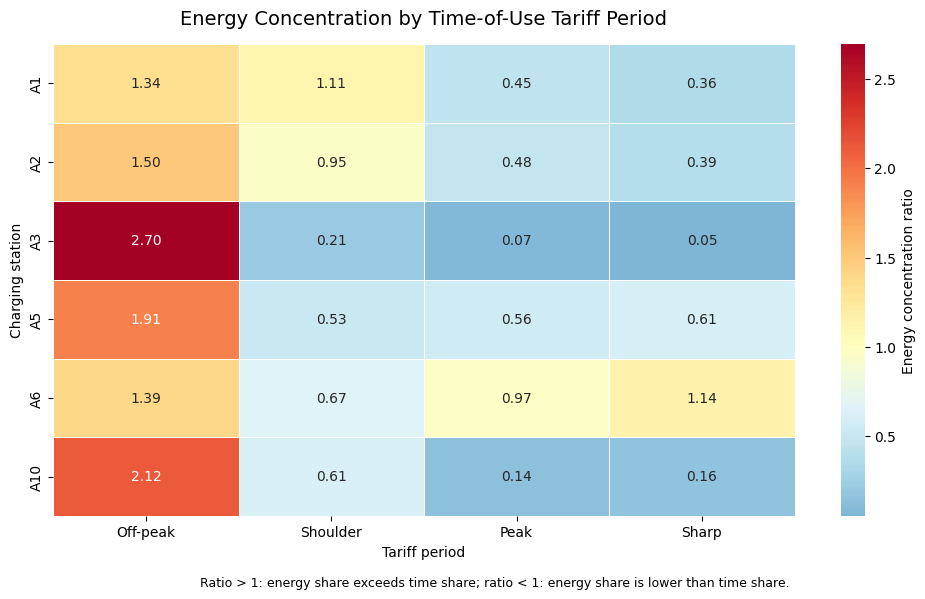

Figure saved: /content/tou_energy_concentration.png
Result tables saved.


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Arrange stations and tariff periods consistently
station_order = ["A1", "A2", "A3", "A5", "A6", "A10"]
period_order = ["Off-peak", "Shoulder", "Peak", "Sharp"]

plot_table = (
    station_tariff_summary.pivot(
        index="station",
        columns="period_type",
        values="concentration_ratio"
    )
    .reindex(index=station_order, columns=period_order)
)

plt.figure(figsize=(10, 5.8))

ax = sns.heatmap(
    plot_table,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=1,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={
        "label": "Energy concentration ratio"
    }
)

ax.set_title(
    "Energy Concentration by Time-of-Use Tariff Period",
    fontsize=14,
    pad=14
)
ax.set_xlabel("Tariff period")
ax.set_ylabel("Charging station")

plt.figtext(
    0.5,
    -0.02,
    "Ratio > 1: energy share exceeds time share; "
    "ratio < 1: energy share is lower than time share.",
    ha="center",
    fontsize=9
)

plt.tight_layout()

figure_path = "/content/tou_energy_concentration.png"
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path)

# Save the supporting result tables
station_tariff_summary.to_csv(
    "/content/tou_station_period_summary.csv",
    index=False
)

tariff_coverage.reset_index().to_csv(
    "/content/tou_tariff_coverage_audit.csv",
    index=False
)

print("Result tables saved.")

In [103]:
from pathlib import Path
import zipfile

results_folder = Path("/content/tou_results")
results_folder.mkdir(exist_ok=True)

# Save tables inside the results folder
station_tariff_summary.to_csv(
    results_folder / "tou_station_period_summary.csv",
    index=False
)

tariff_coverage.reset_index().to_csv(
    results_folder / "tou_tariff_coverage_audit.csv",
    index=False
)

priced_load.loc[
    priced_load["tariff_status"].ne("Priced")
].to_csv(
    results_folder / "excluded_tariff_intervals.csv",
    index=False
)

# Copy the figure into the results folder
import shutil

shutil.copy(
    "/content/tou_energy_concentration.png",
    results_folder / "tou_energy_concentration.png"
)

# Create a short methodology note
method_note = """
MP-EVData Time-of-Use Price Response Analysis

Included stations:
A1, A2, A3, A5, A6 and A10.

Exclusions:
A4 and A9 had no numerical tariff prices.
A7 and A8 recorded charging or swapping counts rather than electrical power.
A5 contained 248 intervals at 21:00–21:45 in January and December
that were not assigned to any tariff period in the source workbook.
These intervals were retained for auditing but excluded from tariff calculations.

Method:
Energy in each 15-minute interval was calculated as power_kW × 0.25 hours.
The energy concentration ratio was calculated as:

energy share (%) / time share (%)

A ratio above 1 indicates that a tariff period contains more charging
energy than expected from its duration. Results are descriptive and do
not establish causal price elasticity because tariff periods coincide
with recurring station operating schedules.
""".strip()

(results_folder / "METHOD_NOTE.txt").write_text(
    method_note,
    encoding="utf-8"
)

# Create ZIP archive
zip_path = Path("/content/tou_price_response_results.zip")

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(results_folder.iterdir()):
        archive.write(path, arcname=path.name)

print("ZIP created:", zip_path)
print("Included files:")

for path in sorted(results_folder.iterdir()):
    print("-", path.name)

ZIP created: /content/tou_price_response_results.zip
Included files:
- METHOD_NOTE.txt
- excluded_tariff_intervals.csv
- tou_energy_concentration.png
- tou_station_period_summary.csv
- tou_tariff_coverage_audit.csv


In [104]:
print(type(aligned_power))
print(aligned_power.shape)
print(aligned_power.head())

<class 'pandas.core.frame.DataFrame'>
(9216, 8)
                        A1      A2      A3      A4   A5    A6     A9  A10
datetime                                                                 
2024-09-27 00:00:00  286.9  2052.6  2992.4  4153.9  5.9  44.8  749.5  0.0
2024-09-27 00:15:00  329.6  1951.7  3027.2  6002.1  5.9  44.8  892.9  0.0
2024-09-27 00:30:00  227.9  1841.8  3049.8  6609.9  5.9  42.0  605.6  0.0
2024-09-27 00:45:00  119.8  1601.5  2933.9  6870.2  5.9  38.1  410.1  0.0
2024-09-27 01:00:00  164.1  1466.7  2691.8  7198.4  5.9  38.1  366.8  0.0


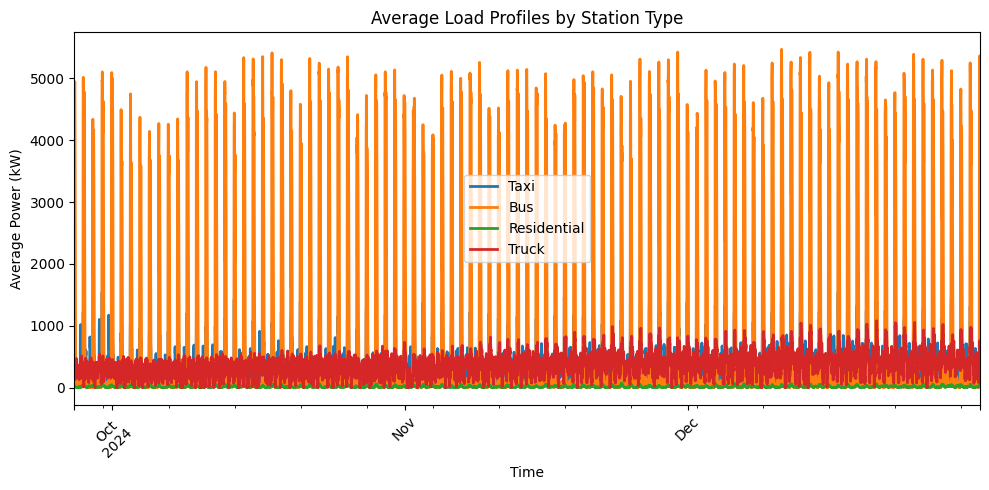

Saved:
/content/figures_used/02_station_type_comparison.png


In [105]:
import matplotlib.pyplot as plt
from pathlib import Path

# Save folder
save_folder = Path("/content/figures_used")
save_folder.mkdir(exist_ok=True)

# Define station types
station_types = {
    "Taxi": ["A1", "A2"],
    "Bus": ["A3", "A4"],
    "Residential": ["A5", "A6"],
    "Truck": ["A9", "A10"]
}

plt.figure(figsize=(10,5))

for name, stations in station_types.items():
    aligned_power[stations].mean(axis=1).plot(
        label=name,
        linewidth=2
    )

plt.xlabel("Time")
plt.ylabel("Average Power (kW)")
plt.title("Average Load Profiles by Station Type")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Save
figure_path = save_folder / "02_station_type_comparison.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure_path)

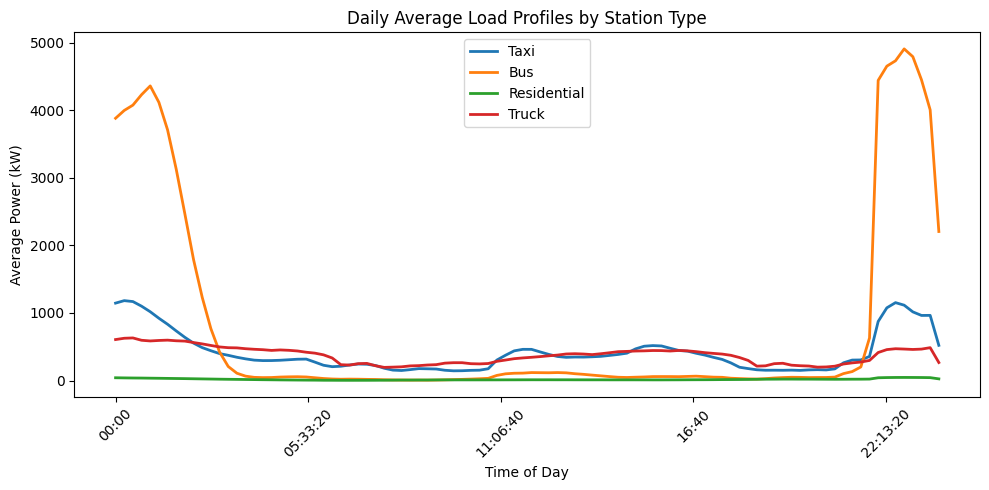

Saved:
/content/figures_used/02_station_type_comparison_daily.png


In [106]:
import matplotlib.pyplot as plt
from pathlib import Path

# Save folder
save_folder = Path("/content/figures_used")
save_folder.mkdir(exist_ok=True)

# Add time-of-day information
daily_power = aligned_power.copy()
daily_power["time"] = daily_power.index.time

# Average each 15-minute interval across all days
daily_profile = daily_power.groupby("time").mean()

# Station type groups
station_types = {
    "Taxi": ["A1", "A2"],
    "Bus": ["A3", "A4"],
    "Residential": ["A5", "A6"],
    "Truck": ["A9", "A10"]
}

# Plot daily profiles
plt.figure(figsize=(10,5))

for name, stations in station_types.items():
    daily_profile[stations].mean(axis=1).plot(
        label=name,
        linewidth=2
    )

plt.xlabel("Time of Day")
plt.ylabel("Average Power (kW)")
plt.title("Daily Average Load Profiles by Station Type")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Save
figure_path = save_folder / "02_station_type_comparison_daily.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(figure_path)

In [107]:
import os

for root, dirs, files in os.walk("/content/MP_EVData_Project"):
    for file in files:
        if "average_curves.csv" in file or "metrics" in file:
            print(os.path.join(root,file))

In [115]:
import shutil
from pathlib import Path

project_results = Path("/content/MP_EVData_Project/results")
project_results.mkdir(exist_ok=True)

folders = [
    "A1_results",
    "residential_results",
    "truck_results",
    "bus_comparison",
    "battery_swap_results",
    "kmeans_results",
    "rf_shap_results",
    "simultaneity_results",
    "tou_price_response_results"
]

for folder in folders:
    src = Path("/content") / folder

    if src.exists():
        shutil.copytree(
            src,
            project_results / folder,
            dirs_exist_ok=True
        )
        print("Copied:", folder)
    else:
        print("Not found:", folder)

print("Finished")

Copied: A1_results
Copied: residential_results
Copied: truck_results
Copied: bus_comparison
Copied: battery_swap_results
Copied: kmeans_results
Copied: rf_shap_results
Copied: simultaneity_results
Not found: tou_price_response_results
Finished


In [116]:
import os

print(os.listdir("/content/MP_EVData_Project/results"))

['bus_comparison', 'kmeans_results', 'residential_results', 'rf_shap_results', 'simultaneity_results', 'A1_results', 'truck_results', 'battery_swap_results']


In [117]:
import pandas as pd
import os

files = [
    "/content/MP_EVData_Project/results/A1_results/A1_daily_metrics_2024.csv",
    "/content/MP_EVData_Project/results/residential_results/A5_daily_metrics_2024.csv",
    "/content/MP_EVData_Project/results/residential_results/A6_daily_metrics_2024.csv",
    "/content/MP_EVData_Project/results/truck_results/A9_daily_metrics_2024.csv",
    "/content/MP_EVData_Project/results/truck_results/A10_daily_metrics_2024.csv",
]

for f in files:
    df = pd.read_csv(f)
    print("\n", os.path.basename(f))
    print(df.columns.tolist())


 A1_daily_metrics_2024.csv
['date', 'intervals', 'average_kW', 'peak_kW', 'valley_kW', 'peak_valley_kW', 'load_factor', 'energy_kWh']

 A5_daily_metrics_2024.csv
['date', 'intervals', 'average_kW', 'peak_kW', 'valley_kW', 'peak_valley_kW', 'load_factor', 'energy_kWh']

 A6_daily_metrics_2024.csv
['date', 'intervals', 'average_kW', 'peak_kW', 'valley_kW', 'peak_valley_kW', 'load_factor', 'energy_kWh']

 A9_daily_metrics_2024.csv
['date', 'intervals', 'average_kW', 'peak_kW', 'valley_kW', 'peak_valley_kW', 'load_factor', 'energy_kWh']

 A10_daily_metrics_2024.csv
['date', 'intervals', 'average_kW', 'peak_kW', 'valley_kW', 'peak_valley_kW', 'load_factor', 'energy_kWh']


In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import os

results = []

# Taxi (A1 represents A1-A2 group)
df = pd.read_csv(
    "/content/MP_EVData_Project/results/A1_results/A1_daily_metrics_2024.csv"
)
results.append([
    "Taxi",
    df["peak_valley_kW"].mean(),
    df["load_factor"].mean()
])


# Residential (A5 + A6)
for station in ["A5", "A6"]:
    pass

res_values = []

for station in ["A5", "A6"]:
    df = pd.read_csv(
        f"/content/MP_EVData_Project/results/residential_results/{station}_daily_metrics_2024.csv"
    )
    res_values.append([
        df["peak_valley_kW"].mean(),
        df["load_factor"].mean()
    ])

results.append([
    "Residential",
    sum(x[0] for x in res_values)/2,
    sum(x[1] for x in res_values)/2
])


# Heavy-duty truck (A9 + A10)
truck_values=[]

for station in ["A9","A10"]:
    df=pd.read_csv(
        f"/content/MP_EVData_Project/results/truck_results/{station}_daily_metrics_2024.csv"
    )
    truck_values.append([
        df["peak_valley_kW"].mean(),
        df["load_factor"].mean()
    ])

results.append([
    "Heavy-duty Truck",
    sum(x[0] for x in truck_values)/2,
    sum(x[1] for x in truck_values)/2
])


summary=pd.DataFrame(
    results,
    columns=[
        "Station_Type",
        "Peak_Valley_kW",
        "Load_Factor"
    ]
)

summary

,Station_Type,Peak_Valley_kW,Load_Factor
0,Taxi,868.218306,0.316599
1,Residential,50.335929,0.304899
2,Heavy-duty Truck,802.330635,0.401937


In [119]:
import pandas as pd

# Bus
bus_file = "/content/MP_EVData_Project/results/bus_comparison/A3_A4_average_curves.csv"

bus_df = pd.read_csv(bus_file)

print("BUS columns:")
print(bus_df.columns.tolist())
print(bus_df.head())

BUS columns:
['slot', 'A3_mean_power_kW', 'A4_mean_power_kW']
   slot  A3_mean_power_kW  A4_mean_power_kW
0     0       2541.649727       5683.115574
1     1       2585.674044       5823.578689
2     2       2592.790710       6055.405191
3     3       2577.252732       6523.515027
4     4       2516.417760       6814.596448


In [120]:
# Battery swap
battery_file = "/content/MP_EVData_Project/results/battery_swap_results/A7_A8_shared_period_curves.csv"

battery_df = pd.read_csv(battery_file)

print("BATTERY SWAP columns:")
print(battery_df.columns.tolist())
print(battery_df.head())

BATTERY SWAP columns:
['slot', 'A7_mean_count', 'A8_mean_count']
   slot  A7_mean_count  A8_mean_count
0     0       5.281525       0.076246
1     1       4.000000       0.082111
2     2       5.190616       0.043988
3     3       3.891496       0.070381
4     4       5.158358       0.046921


In [121]:
import pandas as pd
import numpy as np

# ---------- BUS ----------
bus_file = "/content/MP_EVData_Project/results/bus_comparison/A3_A4_average_curves.csv"

bus_df = pd.read_csv(bus_file)

bus_total = bus_df["A3_mean_power_kW"] + bus_df["A4_mean_power_kW"]

bus_peak = bus_total.max()
bus_valley = bus_total.min()

bus_peak_valley = bus_peak - bus_valley
bus_load_factor = bus_total.mean() / bus_peak


# ---------- BATTERY SWAP ----------
battery_file = "/content/MP_EVData_Project/results/battery_swap_results/A7_A8_shared_period_curves.csv"

battery_df = pd.read_csv(battery_file)

battery_total = battery_df["A7_mean_count"] + battery_df["A8_mean_count"]

battery_peak = battery_total.max()
battery_valley = battery_total.min()

battery_peak_valley = battery_peak - battery_valley
battery_load_factor = battery_total.mean() / battery_peak


print("Bus:")
print("Peak-Valley:", bus_peak_valley)
print("Load Factor:", bus_load_factor)

print("\nBattery Swap:")
print("Peak-Valley:", battery_peak_valley)
print("Activity Factor:", battery_load_factor)

Bus:
Peak-Valley: 9714.990983606556
Load Factor: 0.18713546169002257

Battery Swap:
Peak-Valley: 5.096774193548387
Activity Factor: 0.568575576863112


In [122]:
import pandas as pd

final_summary = pd.DataFrame({
    "Archetype": [
        "Taxi",
        "Bus",
        "Residential",
        "Battery Swap",
        "Heavy-duty Truck"
    ],
    "Peak_Valley": [
        868.218306,
        9714.990836,
        50.335929,
        5.096774,
        802.330635
    ],
    "Load_Factor": [
        0.316599,
        0.187135,
        0.304899,
        0.568576,
        0.401937
    ]
})

final_summary

,Archetype,Peak_Valley,Load_Factor
0,Taxi,868.218306,0.316599
1,Bus,9714.990836,0.187135
2,Residential,50.335929,0.304899
3,Battery Swap,5.096774,0.568576
4,Heavy-duty Truck,802.330635,0.401937


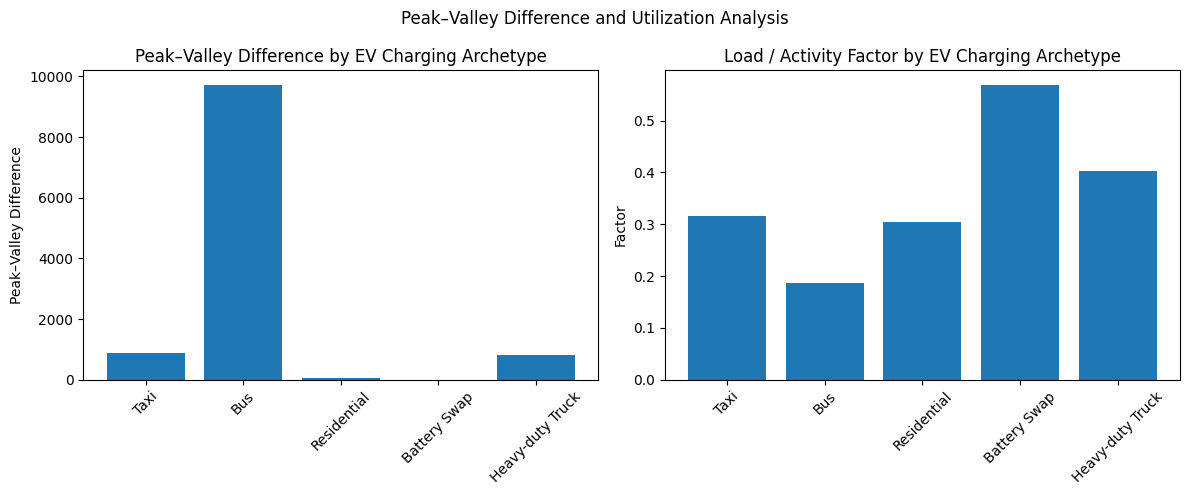

Saved:
/content/MP_EVData_Project/results/peak_valley_load_factor_results/peak_valley_load_factor_by_archetype.png


In [123]:
import matplotlib.pyplot as plt
import os

output = "/content/MP_EVData_Project/results/peak_valley_load_factor_results"

os.makedirs(output, exist_ok=True)

fig, axes = plt.subplots(1,2, figsize=(12,5))


# Peak valley
axes[0].bar(
    final_summary["Archetype"],
    final_summary["Peak_Valley"]
)

axes[0].set_title("Peak–Valley Difference by EV Charging Archetype")
axes[0].set_ylabel("Peak–Valley Difference")
axes[0].tick_params(axis="x", rotation=45)


# Factor
axes[1].bar(
    final_summary["Archetype"],
    final_summary["Load_Factor"]
)

axes[1].set_title("Load / Activity Factor by EV Charging Archetype")
axes[1].set_ylabel("Factor")
axes[1].tick_params(axis="x", rotation=45)


plt.suptitle(
    "Peak–Valley Difference and Utilization Analysis"
)

plt.tight_layout()

plt.savefig(
    f"{output}/peak_valley_load_factor_by_archetype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(f"{output}/peak_valley_load_factor_by_archetype.png")

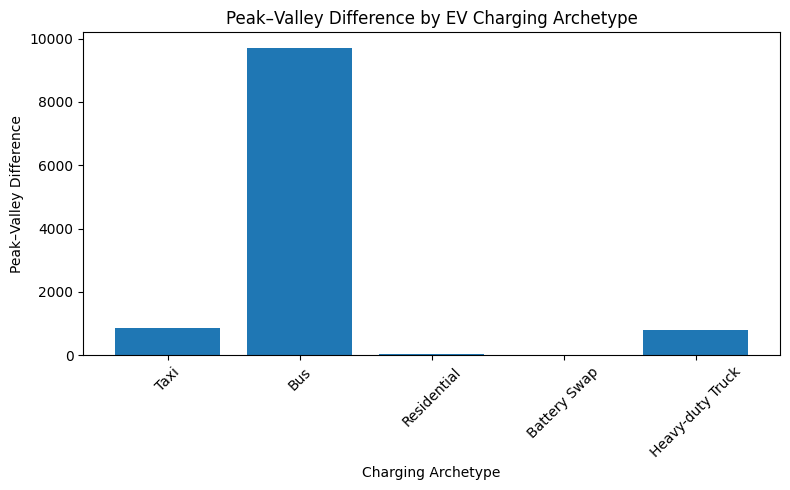

Saved:
/content/MP_EVData_Project/results/peak_valley_load_factor_results/peak_valley_difference_by_archetype.png


In [124]:
import matplotlib.pyplot as plt
import os

output = "/content/MP_EVData_Project/results/peak_valley_load_factor_results"

os.makedirs(output, exist_ok=True)

# Figure 1: Peak–Valley Difference

plt.figure(figsize=(8,5))

plt.bar(
    final_summary["Archetype"],
    final_summary["Peak_Valley"]
)

plt.title("Peak–Valley Difference by EV Charging Archetype")
plt.xlabel("Charging Archetype")
plt.ylabel("Peak–Valley Difference")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{output}/peak_valley_difference_by_archetype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(f"{output}/peak_valley_difference_by_archetype.png")

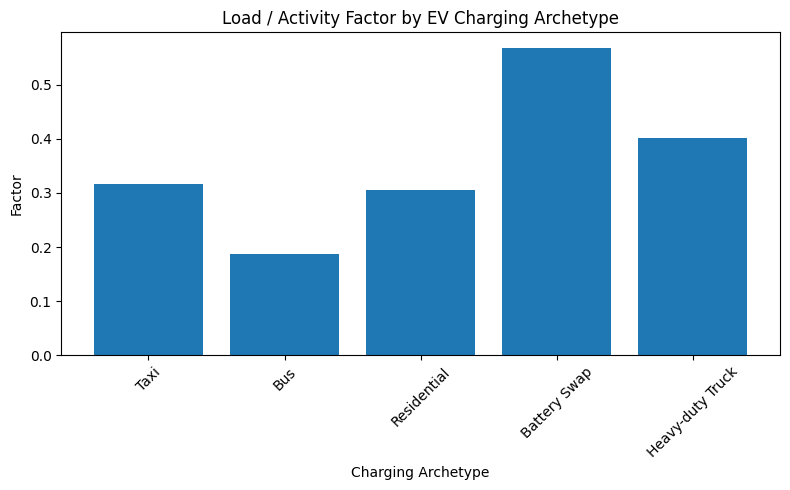

Saved:
/content/MP_EVData_Project/results/peak_valley_load_factor_results/load_activity_factor_by_archetype.png


In [125]:
# Figure 2: Load / Activity Factor

plt.figure(figsize=(8,5))

plt.bar(
    final_summary["Archetype"],
    final_summary["Load_Factor"]
)

plt.title("Load / Activity Factor by EV Charging Archetype")
plt.xlabel("Charging Archetype")
plt.ylabel("Factor")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{output}/load_activity_factor_by_archetype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(f"{output}/load_activity_factor_by_archetype.png")

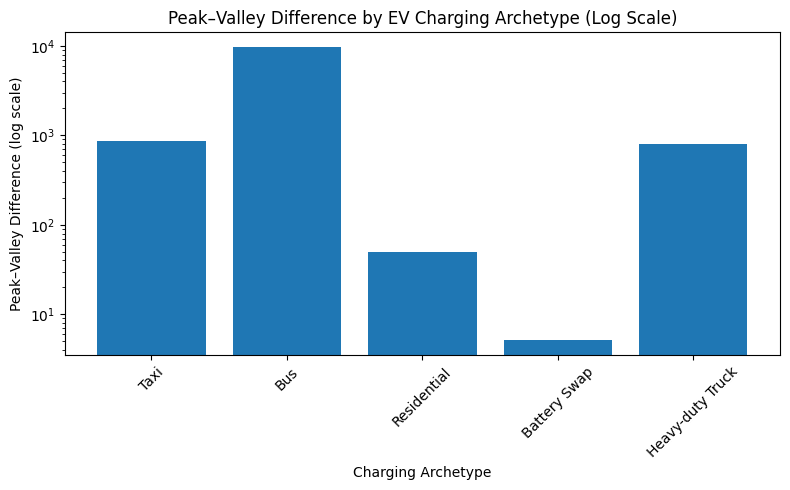

Saved:
/content/MP_EVData_Project/results/peak_valley_load_factor_results/peak_valley_difference_by_archetype_log.png


In [126]:
import matplotlib.pyplot as plt
import os

output = "/content/MP_EVData_Project/results/peak_valley_load_factor_results"

plt.figure(figsize=(8,5))

plt.bar(
    final_summary["Archetype"],
    final_summary["Peak_Valley"]
)

plt.yscale("log")   # <-- this makes the y-axis logarithmic

plt.title("Peak–Valley Difference by EV Charging Archetype (Log Scale)")
plt.xlabel("Charging Archetype")
plt.ylabel("Peak–Valley Difference (log scale)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{output}/peak_valley_difference_by_archetype_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(f"{output}/peak_valley_difference_by_archetype_log.png")